In [2]:
import os
import sys
sys.path.append("../..")

import dill as pickle
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.distributions as td
import torch.nn as nn
import torch.nn.functional as F
import torch_geometric as pyg
from torch_geometric.nn import GCNConv
from torch_geometric.nn import global_mean_pool
from torch_geometric.datasets import TUDataset

from egg_models import egg_generic_losses
from egg_models.egg_generic import EggGeneric
from egg_models.egg_generic import EggGeneric
from functools import partial
from matplotlib.patches import ConnectionPatch
from scipy.stats import gaussian_kde, t
from sklearn.metrics import confusion_matrix

from utils import mutag_helper
from utils import visuals
import pygmtools as pygm
import networkx as nx

from egg_models.egg_generic_losses import activation_hook, dict_cos_dist, GEDasMatchLoss
from scipy.stats import stats

2024-10-06 01:56:52.791466: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2024-10-06 01:57:10.001483: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT


In [3]:
# Reproducibility
SEED = 123123
torch.manual_seed(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = True 
np.random.seed(SEED)

#Meta-Data
device = torch.device(0)
node_types = ['C', 'N', 'O', 'F', "I", "Cl", 'Br']
edge_types = ['aromatic', 'single', 'double', 'triple']
color_palette = np.array(['orange', 'magenta', 'green', 'blue', 'cyan', 'red', 'lime'])
color_palette_dropped = np.array(['orange', 'magenta', 'green', 'blue', 'red'])

# Data Prep

## Helper Functions

In [4]:
# Explainee Model
class GCN(torch.nn.Module):
    def __init__(self, node_features, hc1=64, hc2=32, hc3=16):
        super().__init__()
        torch.manual_seed(12345)
        self.conv1 = GCNConv(node_features, hc1)
        self.conv2 = GCNConv(hc1, hc2)
        self.conv3 = GCNConv(hc2, hc3)
        self.lin = nn.Linear(hc3, 2)

    def forward(self, data):
        x, edge_index, batch = data.x, data.edge_index, data.batch

        # 1. Obtain node embeddings 
        x = self.conv1(x, edge_index)
        x = x.relu()
        x = self.conv2(x, edge_index)
        x = x.relu()
        x = self.conv3(x, edge_index)

        # 2. Readout layer
        x = global_mean_pool(x, batch)  # [batch_size, hidden_channels]

        # 3. Apply a final classifier
        x = F.dropout(x, p=0.5, training=self.training)
        x = self.lin(x)
        
        return x

In [5]:
def train_explainee(
    explainee: nn.Module,
    train_data: list, 
    test_data: list, 
    ):

    train_data_loader = pyg.loader.DataLoader(train_data, 
                                            batch_size=16, shuffle=True)
    test_data_loader = pyg.loader.DataLoader(test_data, 
                                            batch_size=16, shuffle=False)

    optimizer = torch.optim.Adam(explainee.parameters(), lr=0.001)
    criterion = torch.nn.CrossEntropyLoss()

    for epoch in range(201): 
        explainee.train()        
        for batch in train_data_loader: 
            out = explainee(batch)
            loss = criterion(out, batch.y)
            loss.backward()

            optimizer.step()
            optimizer.zero_grad()

        explainee.eval()
        correct = 0
        for batch in train_data_loader: 
            out = explainee(batch)
            pred = out.argmax(dim=1)
            correct += int((pred == batch.y).sum())

        train_accuracy = correct / len(train_data_loader.dataset)

        correct = 0
        for batch in test_data_loader: 
            out = explainee(batch)
            pred = out.argmax(dim=1)
            correct += int((pred == batch.y).sum())

        test_accuracy = correct / len(test_data_loader.dataset)

        print(f"Epoch: {epoch} Train Accuracy: {train_accuracy} " + 
            f"Test Accuracy: {test_accuracy}")


    full_batch = pyg.data.Batch.from_data_list(test_data)
    explainee.eval()
    preds = explainee(full_batch).argmax(dim=1).numpy()
    targets = full_batch.y.numpy()

    conf_matrix = confusion_matrix(targets, preds)
    print(conf_matrix)

    return explainee

In [6]:
def extract_embeddings(
    explainee: nn.Module, 
    train_data: list, 
    ):

    activation_names = ["conv1", "conv2", "conv3"]
    train_avg_embedding_0 = {"conv1": [], "conv2": [], "conv3": []}
    train_avg_embedding_1 = {"conv1": [], "conv2": [], "conv3": []}
    pool_func = pyg.nn.global_mean_pool


    train_data_loader = pyg.loader.DataLoader(train_data)
    for batch in train_data_loader:
        explainee.eval()

        acts, remove_hooks = activation_hook(explainee, activation_names)
        out = explainee(batch)
        remove_hooks()

        if batch.y.item() == 0: 
            for name in activation_names: 
                embed = pool_func(acts[name], batch.batch)
                train_avg_embedding_0[name].append(
                    embed.detach().to('cpu')
                )

        if batch.y.item() == 1: 
            for name in activation_names: 
                embed = pool_func(acts[name], batch.batch)
                train_avg_embedding_1[name].append(
                    embed.detach().to('cpu')
                )
                
    for name in activation_names:
        train_avg_embedding_0[name] = torch.stack(
            train_avg_embedding_0[name]
        ).mean(dim=0)

        train_avg_embedding_1[name] = torch.stack(
            train_avg_embedding_1[name]
        ).mean(dim=0)

    return train_avg_embedding_0, train_avg_embedding_1

## Raw Data

In [7]:
# Raw data

# Download data. 
data_raw = TUDataset(root='data/TUDataset', name='MUTAG')

# Shuffle
data_raw = data_raw.shuffle()

# Split 
train_data = data_raw[:150]
test_data = data_raw[150:]

# Create data lists
train_data_list = []
train_data_list_0 = []
train_data_list_1 = []
test_data_list = []
test_data_list_0 = []
test_data_list_1 = []

for graph in train_data:
    train_data_list.append(graph)

    if graph.y.item() == 0: 
        train_data_list_0.append(graph)

    elif graph.y.item() == 1: 
        train_data_list_1.append(graph)

for graph in test_data:
    test_data_list.append(graph)

    if graph.y.item() == 0: 
        test_data_list_0.append(graph)

    elif graph.y.item() == 1: 
        test_data_list_1.append(graph)

In [8]:
explainee_raw = train_explainee(
    GCN(node_features=7), 
    train_data_list, test_data_list
)

Epoch: 0 Train Accuracy: 0.6466666666666666 Test Accuracy: 0.7368421052631579
Epoch: 1 Train Accuracy: 0.6466666666666666 Test Accuracy: 0.7368421052631579
Epoch: 2 Train Accuracy: 0.6466666666666666 Test Accuracy: 0.7368421052631579
Epoch: 3 Train Accuracy: 0.6466666666666666 Test Accuracy: 0.7368421052631579
Epoch: 4 Train Accuracy: 0.6466666666666666 Test Accuracy: 0.7368421052631579
Epoch: 5 Train Accuracy: 0.6466666666666666 Test Accuracy: 0.7368421052631579
Epoch: 6 Train Accuracy: 0.6466666666666666 Test Accuracy: 0.7368421052631579
Epoch: 7 Train Accuracy: 0.6466666666666666 Test Accuracy: 0.7368421052631579
Epoch: 8 Train Accuracy: 0.6466666666666666 Test Accuracy: 0.7368421052631579
Epoch: 9 Train Accuracy: 0.6466666666666666 Test Accuracy: 0.7368421052631579
Epoch: 10 Train Accuracy: 0.6466666666666666 Test Accuracy: 0.7368421052631579
Epoch: 11 Train Accuracy: 0.6466666666666666 Test Accuracy: 0.7368421052631579
Epoch: 12 Train Accuracy: 0.6466666666666666 Test Accuracy: 0.

In [9]:
train_avg_embedding_0, train_avg_embedding_1 = extract_embeddings(
    explainee_raw, train_data_list
)
print(train_avg_embedding_0)
print(train_avg_embedding_1)

{'conv1': tensor([[-2.5616e-02,  3.5865e-02,  2.2708e-02, -6.0919e-02,  1.1478e-01,
         -5.7976e-02,  1.5329e-01, -5.8544e-02,  3.1236e-01,  7.9226e-03,
         -1.5723e-01,  7.3637e-02,  5.1356e-03, -8.6245e-02, -1.9665e-01,
         -4.6060e-03, -2.4553e-02,  2.6134e-03,  8.7952e-05, -1.6012e-01,
         -3.5422e-02,  1.2097e-01,  7.3860e-02, -1.3997e-01,  1.7250e-02,
          2.4613e-02, -6.1222e-02,  1.6407e-01, -3.2518e-01,  1.7116e-01,
         -3.1727e-02, -1.1589e-01,  4.7401e-03, -1.2909e-01,  7.1675e-02,
         -4.0509e-02, -7.7566e-02,  5.2777e-02, -4.0029e-03,  1.4338e-01,
         -6.6134e-02,  1.6166e-02,  4.7563e-02, -3.2336e-02, -4.8085e-02,
         -1.2039e-01, -1.2067e-01,  5.8204e-02, -6.6188e-03,  2.4483e-03,
          1.2473e-02,  7.1323e-02, -2.3756e-02, -1.6651e-01,  1.5828e-02,
          4.1388e-02, -8.7087e-02,  7.0760e-04, -6.4389e-02, -2.5253e-04,
         -3.3731e-02,  6.5148e-03,  1.2479e-01, -9.7723e-02]]), 'conv2': tensor([[-0.0645, -0.0451,  0

## Dropped

In [9]:
data_dropped = []

for graph in data_raw:
    node_types = graph.x.argmax(dim=-1)
    edge_types = graph.edge_attr.argmax(dim=-1)

    if torch.any(node_types == 4) or torch.any(node_types == 6) or torch.any(edge_types == 3): 
        print(graph) 
    else: 
        graph.x = torch.cat([graph.x[:, :4], graph.x[:, 5].unsqueeze(1)], dim=1)
        graph.edge_attr = graph.edge_attr[:, :3]
        data_dropped.append(graph)

data_dropped[1]

Data(edge_index=[2, 38], x=[17, 7], edge_attr=[38, 4], y=[1])
Data(edge_index=[2, 28], x=[14, 7], edge_attr=[28, 4], y=[1])
Data(edge_index=[2, 38], x=[17, 7], edge_attr=[38, 4], y=[1])
Data(edge_index=[2, 40], x=[18, 7], edge_attr=[40, 4], y=[1])


Data(edge_index=[2, 38], x=[17, 5], edge_attr=[38, 3], y=[1])

In [10]:
# Split 
train_data_dropped = data_dropped[:150]
test_data_dropped = data_dropped[150:]

# Create data lists
train_data_list_dropped = []
train_data_list_dropped_0 = []
train_data_list_dropped_1 = []
test_data_list_dropped = []
test_data_list_dropped_0 = []
test_data_list_dropped_1 = []

for graph in train_data_dropped:
    train_data_list_dropped.append(graph)

    if graph.y.item() == 0: 
        train_data_list_dropped_0.append(graph)

    elif graph.y.item() == 1: 
        train_data_list_dropped_1.append(graph)

for graph in test_data_dropped:
    test_data_list_dropped.append(graph)

    if graph.y.item() == 0: 
        test_data_list_dropped_0.append(graph)

    elif graph.y.item() == 1: 
        test_data_list_dropped_1.append(graph)

In [11]:
explainee_dropped = train_explainee(
    GCN(node_features=5), 
    train_data_list_dropped, 
    test_data_list_dropped
)  

Epoch: 0 Train Accuracy: 0.6466666666666666 Test Accuracy: 0.7352941176470589
Epoch: 1 Train Accuracy: 0.6466666666666666 Test Accuracy: 0.7352941176470589
Epoch: 2 Train Accuracy: 0.6466666666666666 Test Accuracy: 0.7352941176470589
Epoch: 3 Train Accuracy: 0.6466666666666666 Test Accuracy: 0.7352941176470589
Epoch: 4 Train Accuracy: 0.6466666666666666 Test Accuracy: 0.7352941176470589
Epoch: 5 Train Accuracy: 0.6466666666666666 Test Accuracy: 0.7352941176470589
Epoch: 6 Train Accuracy: 0.6466666666666666 Test Accuracy: 0.7352941176470589
Epoch: 7 Train Accuracy: 0.6466666666666666 Test Accuracy: 0.7352941176470589
Epoch: 8 Train Accuracy: 0.6466666666666666 Test Accuracy: 0.7352941176470589
Epoch: 9 Train Accuracy: 0.6466666666666666 Test Accuracy: 0.7352941176470589
Epoch: 10 Train Accuracy: 0.6466666666666666 Test Accuracy: 0.7352941176470589
Epoch: 11 Train Accuracy: 0.6466666666666666 Test Accuracy: 0.7352941176470589
Epoch: 12 Train Accuracy: 0.6466666666666666 Test Accuracy: 0.

In [12]:
train_avg_embedding_0_dropped, train_avg_embedding_1_dropped = extract_embeddings(
    explainee_dropped, train_data_list_dropped
)
print(train_avg_embedding_0_dropped)
print(train_avg_embedding_1_dropped)

{'conv1': tensor([[-0.0276,  0.0798,  0.1924,  0.1729, -0.0075,  0.1216,  0.0237,  0.1757,
          0.1126, -0.0739, -0.0710, -0.0031, -0.0275, -0.0070,  0.0217, -0.0237,
          0.0092,  0.0541, -0.0590,  0.0186, -0.1923, -0.0211,  0.1099,  0.0057,
         -0.0199, -0.0091,  0.1507,  0.0507, -0.0247,  0.0169,  0.0005,  0.1497,
          0.0133,  0.0581,  0.1614, -0.0114, -0.0009, -0.0009, -0.0342,  0.0246,
         -0.0813, -0.0117,  0.0851, -0.1581, -0.0043, -0.2818,  0.1122,  0.0074,
          0.1568,  0.0783, -0.0099,  0.0165,  0.0343,  0.1089, -0.0192,  0.1614,
         -0.0093,  0.1375,  0.0141,  0.0689,  0.1716, -0.0262,  0.0517,  0.0913]]), 'conv2': tensor([[-0.1885,  0.1674,  0.1749, -0.1000,  0.0770,  0.1459,  0.2849,  0.1932,
         -0.0510,  0.0812, -0.1993, -0.2232,  0.1412, -0.2686, -0.2893, -0.2965,
         -0.2149, -0.1909, -0.0599, -0.2064, -0.1401,  0.1115,  0.1477, -0.0557,
          0.1658,  0.2561,  0.1316, -0.1155, -0.1595, -0.1507,  0.1499,  0.1483]]), 'co

# EGG

## Helper Functions

In [11]:
def t_confidence_interval(data):
    mean = np.mean(data)
    std_dev = np.std(data)
    n = len(data)
    t_value = t.ppf(0.975, df=n-1) 
    margin_of_error = t_value * (std_dev / np.sqrt(n))
    lower_bound = np.round(mean - margin_of_error, 4)
    upper_bound = np.round(mean + margin_of_error, 4)

    print(f"({lower_bound}, {upper_bound})")

In [12]:
def pre_acc_interval(
    generator: nn.Module, 
    explainee: nn.Module, 
    target
    ):
    generator.eval()
    explainee.eval()

    pred_acc = []
    for i in range(100):
        with torch.no_grad():
            gen_ex = mutag_helper.egg_to_ex(generator())
            pred = torch.softmax(explainee(gen_ex), dim=-1).mean(dim=0)
            pred_acc.append(pred[target].item())
    
    t_confidence_interval(pred_acc)

In [13]:
def GED_interval(
    generator: nn.Module, 
    GED_fn: nn.Module, 
    data_list: list, 
    batch_size=16, 
    ):
    generator.eval()
    loader = pyg.loader.DataLoader(data_list, 
                                   batch_size=batch_size, drop_last=True)
    running_GED = []
    for batch in loader:
        batch = batch.to(device)
        with torch.no_grad():
            generated = generator()
            gen_ex = mutag_helper.egg_to_ex(generated)
            gen_egg = mutag_helper.egg_to_egg(generated)
            obs_egg = mutag_helper.ex_to_egg(batch)

            egg_sizes = torch.tensor([
                graph.x.shape[0] + graph.edge_index.shape[1] 
                for graph in gen_ex.to_data_list()
            ]).to(device)

            loss = (
                GED_fn(*gen_egg, *obs_egg) / 
                egg_sizes
            ).mean()

            running_GED.append(min(loss.item(), 1.0))

    t_confidence_interval(running_GED)

In [14]:
def train_egg(
    dis_node_feats: int, 
    dis_edge_feats: int, 
    explainee: nn.Module, 
    target: int, 
    train_data_list_1, 
    train_data_list_0, 
    train_data_list_full, 
    pred_loss_embeds, 
    other_class_embeds,  
    max_node_size=20, 
    temp=0.15, 
    epochs=25, 
    loss_fn_weights=torch.tensor([1.0, 1.0, 1.0, 1.0]), 
    use_egg_size=False, 
    use_omega=True,  
    batch_size=16
    ):
    # Define target tensors. 
    if target == 1:
        target_tensor = torch.tensor([0.0, 1.0])
    else: 
        target_tensor = torch.tensor([1.0, 0.0])

    # Setup explainee. 
    explainee.eval()
    explainee.to(device)

    # Define generator to train. 
    generator = EggGeneric(
        max_node_size=max_node_size,
        cont_node_feats=None, 
        cont_edge_feats=None, 
        dis_node_feats=(dis_node_feats, ), 
        dis_edge_feats=(dis_edge_feats, ), 
        temp=temp, 
        batch_size=batch_size, 
    )
    generator.to(device)

    # Define GED function.
    GED_fn = egg_generic_losses.GEDasMatchLoss(
        node_size=max_node_size, 
        cont_node_indices=None, 
        cont_edge_indices=None, 
        dis_node_indices=(slice(0, dis_node_feats), ),  
        dis_edge_indices=(slice(0, dis_edge_feats), dis_edge_feats), 
        QAP_solver=pygm.ngm, 
    )

    # Compute random baseline.
    print("Baseline Prediction Accuracy: ")
    pre_acc_interval(generator, explainee, target)
    print(f"Baseline % GED to 1")
    GED_interval(generator, GED_fn, train_data_list_1)
    print(f"Baseline % GED to 0")
    GED_interval(generator, GED_fn, train_data_list_0)

    # Train EGG model.
    train_loader = pyg.loader.DataLoader(train_data_list_full, 
                                         batch_size=batch_size, drop_last=True)
    pred_loss_fn = egg_generic_losses.PredLossBatched(
        target_tensor, explainee, avg_embed_targets=pred_loss_embeds
    )
    embed_dist_fn = egg_generic_losses.EmbDistGeneric(
        explainee, avg_embed_targets=other_class_embeds
    )
    edge_pen_fn = egg_generic_losses.EdgePenalty(edge_budget = 10)
    generator.train()
    optimizer = torch.optim.RMSprop(generator.parameters()) 
    for epoch in range(epochs):
        report_loss = np.array([0.0, 0.0, 0.0, 0.0])
        for obs_batch in train_loader: 
            optimizer.zero_grad()
            obs_batch = obs_batch.to(device)
            gen_graph = generator()

            # Data formatting. 
            gen_ex = mutag_helper.egg_to_ex(gen_graph) 
            gen_egg = mutag_helper.egg_to_egg(gen_graph)
            obs_egg = mutag_helper.ex_to_egg(obs_batch)

            loss_1, _, _ = pred_loss_fn(gen_ex)
            loss_1 = loss_1.mean()

            loss_embed = -1 * embed_dist_fn(gen_ex).mean()

            #loss_edge = torch.sum(generator.AdjacencyMatrix.probs, dim=0).mean()
            loss_edge = edge_pen_fn(generator.AdjacencyMatrix.probs)

            loss_2 = GED_fn(*gen_egg, *obs_egg)
            if use_egg_size:
                egg_size = torch.tensor([
                    graph.x.shape[0] + graph.edge_index.shape[1] 
                    for graph in gen_ex.to_data_list()
                ]).to(loss_2.device)
            else: 
                egg_size = 1.0
            
            if use_omega:
                with torch.no_grad():
                    explainee_pred = F.softmax(explainee(obs_batch), dim=-1)
                    omega = (explainee_pred @ 
                        target_tensor.to(explainee_pred.device) - 0.5
                    )
            else:
                omega = 1
            loss_3 = (omega * loss_2 / egg_size).mean()

            report_loss += [loss_1.item(), loss_embed.item(), 
                            loss_edge.item(), loss_3.item()]
            report_loss
            loss = (
                loss_fn_weights.to(loss_1.device) @ 
                torch.stack((loss_1, loss_embed, loss_edge, loss_3)) 
            )

            loss.backward()

            torch.nn.utils.clip_grad_norm_(generator.parameters(), 1.0)

            optimizer.step() 

        report_loss = [x / len(train_loader) for x in report_loss]
        print(f"Epoch: {epoch} Losses:{report_loss}")

    print("Trained Prediction Accuracy: ")
    pre_acc_interval(generator, explainee, target)
    print(f"Trained % GED to 1")
    GED_interval(generator, GED_fn, train_data_list_1)
    print(f"Trained % GED to 0")
    GED_interval(generator, GED_fn, train_data_list_0)

    return generator 

In [15]:
# Visualize Connected Graph
def vis_con_graph(
    generator: nn.Module, 
    explainee: nn.Module, 
    dis_node_feats: int, 
    dis_edge_feats: int, 
    target: int, 
    obs_ex1, 
    obs_ex2, 
    color_palette=color_palette
    ):

    generator_batch_1 = EggGeneric(
        max_node_size=generator.max_node_size,
        cont_node_feats=None, 
        cont_edge_feats=None, 
        dis_node_feats=(dis_node_feats, ), 
        dis_edge_feats=(dis_edge_feats, ), 
        temp=generator.temp, 
        batch_size=1, 
    )
    generator_batch_1.load_state_dict(generator.state_dict())
    generator_batch_1.to(device)

    # Define GED function.
    GED_fn = egg_generic_losses.GEDasMatchLoss(
        node_size=generator.max_node_size, 
        cont_node_indices=None, 
        cont_edge_indices=None, 
        dis_node_indices=(slice(0, dis_node_feats), ),  
        dis_edge_indices=(slice(0, dis_edge_feats), dis_edge_feats), 
        QAP_solver=pygm.ngm, 
    )

    gen = generator_batch_1()
    gen_ex = mutag_helper.egg_to_ex(gen)
    gen_egg = mutag_helper.egg_to_egg(gen)
    colors0 = color_palette[torch.argmax(gen_ex.x, dim=-1).cpu().numpy()]
    gen_nx = pyg.utils.to_networkx(gen_ex)

    obs_ex1 = obs_ex1.to(device)
    obs_egg1 = mutag_helper.ex_to_egg(pyg.data.Batch().from_data_list([obs_ex1]))
    colors1 = color_palette[torch.argmax(obs_ex1.x, dim=-1).cpu().numpy()]
    obs_nx = pyg.utils.to_networkx(obs_ex1)

    obs_ex2 = obs_ex2.to(device)
    obs_egg2 = mutag_helper.ex_to_egg(pyg.data.Batch().from_data_list([obs_ex2]))
    colors2 = color_palette[torch.argmax(obs_ex2.x, dim=-1).cpu().numpy()]
    obs_nx2 = pyg.utils.to_networkx(obs_ex2)

    with torch.no_grad():
        aff_mat = GED_fn.get_aff_mat(*gen_egg, *obs_egg1)
        dis_match_mat = GED_fn.get_dis_match_mat(aff_mat)

    with torch.no_grad():
        aff_mat2 = GED_fn.get_aff_mat(*gen_egg, *obs_egg2)
        dis_match_mat2 = GED_fn.get_dis_match_mat(aff_mat2)

    egg_size = torch.tensor([
        graph.x.shape[0] + graph.edge_index.shape[1] 
        for graph in gen_ex.to_data_list()
    ]).to(device)

    GED_score1 = (
        -1 * pygm.utils.compute_affinity_score(dis_match_mat, aff_mat) / 
        egg_size
    ).item()
    GED_score1 = min(GED_score1, 1.0) # cap at 100% edit.

    GED_score2 = (
        -1 * pygm.utils.compute_affinity_score(dis_match_mat2, aff_mat2) / 
        egg_size
    ).item()
    GED_score2 = min(GED_score2, 1.0)


    pos_1 = nx.spring_layout(obs_nx)
    # pos_2 = nx.spring_layout(gen_nx)
    pos_2 = {}
    for i in range(gen_ex.x.shape[0]):
        j = torch.argmax(dis_match_mat.squeeze()[i]).item()
        pos_2[i] = pos_1[j]

    fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharex=True, sharey=True)

    nx.draw(obs_nx, node_color = colors1, pos = pos_1, ax=axes[0])

    nx.draw(gen_nx, node_color = colors0, pos=pos_2, ax=axes[1])

    for i in range(gen_ex.x.shape[0]):
        j = torch.argmax(dis_match_mat.squeeze()[i]).item()
        con = ConnectionPatch(xyA=pos_2[i], xyB=pos_1[j], 
                            coordsA="data", coordsB="data",
                            axesA=axes[0], axesB=axes[1], color="green")

        fig.add_artist(con)

    pos_3 = nx.spring_layout(obs_nx2)
    for i in range(gen_ex.x.shape[0]):
        j = torch.argmax(dis_match_mat2.squeeze()[i]).item()
        pos_3[j] = pos_2[i]

    nx.draw(obs_nx2, node_color = colors2, pos = pos_3, ax=axes[2])

    for i in range(gen_ex.x.shape[0]):
        j = torch.argmax(dis_match_mat2.squeeze()[i]).item()
        con = ConnectionPatch(xyA=pos_3[j], xyB=pos_2[i], 
                            coordsA="data", coordsB="data",
                            axesA=axes[2], axesB=axes[1], color="blue")

        fig.add_artist(con)

    explainee.eval()
    with torch.no_grad():
        pred_gen = torch.softmax(explainee(gen_ex), -1)[:, target].item()
        pred_obs1 = torch.softmax(explainee(obs_ex1), -1)[:, target].item()
        pred_obs2 = torch.softmax(explainee(obs_ex2), -1)[:, target].item()

    axes[0].set_title(f"Class Probability: {pred_obs1:0.2f} GED: {GED_score1:0.2f}")
    axes[1].set_title(f"Class Probability: {pred_gen:0.2f}")
    axes[2].set_title(f"GED: {GED_score2:0.2f} Class Probability: {pred_obs2:0.2f}")

# Results

## Re-implementationn of GNNInterpreter

In [18]:
gen_gnnInt_1 = train_egg(
    dis_node_feats=7, 
    dis_edge_feats=4,
    explainee=explainee_raw, 
    target=1,
    train_data_list_1=train_data_list_1 + test_data_list_1, 
    train_data_list_0=train_data_list_0 + train_data_list_0, 
    train_data_list_full=train_data_list + test_data_list, 
    pred_loss_embeds=dict(
        (k, train_avg_embedding_1[k]) 
        for k in ["conv3"] if k in train_avg_embedding_1
    ), 
    other_class_embeds=dict(
        (k, train_avg_embedding_0[k]) 
        for k in ["conv3"] if k in train_avg_embedding_0
    ), 
    loss_fn_weights = torch.tensor([1.0, 0.0, 1e-5, 0.0]), 
)

Baseline Prediction Accuracy: 
(0.0346, 0.0478)
Baseline % GED to 1
(0.0887, 0.0943)
Baseline % GED to 0
(0.0702, 0.0802)
Epoch: 0 Losses:[2.488895145329562, -0.4473442055962302, 11162.2568359375, 2.6499658010222693]
Epoch: 1 Losses:[1.3407070420005105, -1.2012389681556008, 2753.4923761541195, 2.7455567988482388]
Epoch: 2 Losses:[0.9785756414586847, -1.4791967110200361, 978.0284257368608, 2.824252887205644]
Epoch: 3 Losses:[0.9173111753030256, -1.5128273096951572, 351.09116294167256, 2.872792428190058]
Epoch: 4 Losses:[0.717555205930363, -1.6518840464678677, 138.54642833362925, 2.9109406904740767]
Epoch: 5 Losses:[0.7866713621399619, -1.615212158723311, 54.05634585293856, 2.9942910129373725]
Epoch: 6 Losses:[0.6482593308795582, -1.7099301381544634, 21.848096414045855, 2.9805338707837192]
Epoch: 7 Losses:[0.5527355914766138, -1.7755876562812112, 9.964752587405117, 2.9764183326201006]
Epoch: 8 Losses:[0.5462479022416201, -1.7838731570677324, 5.354430545460094, 2.9984213438901035]
Epoch: 

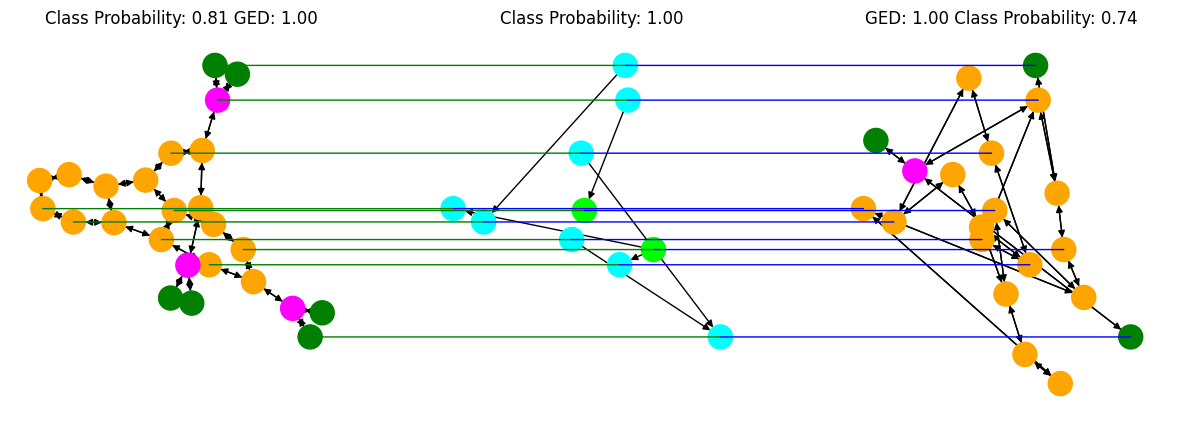

In [19]:
vis_con_graph(
    gen_gnnInt_1, 
    explainee_raw, 
    dis_node_feats = 7,
    dis_edge_feats = 4, 
    obs_ex1=test_data_list_1[1].clone(), 
    obs_ex2=test_data_list_1[5].clone(), 
    target=1
)

In [20]:
gen_gnnInt_0 = train_egg(
    dis_node_feats=7, 
    dis_edge_feats=4,
    explainee=explainee_raw, 
    target=0,
    train_data_list_1=train_data_list_1 + test_data_list_1, 
    train_data_list_0=train_data_list_0 + train_data_list_0, 
    train_data_list_full=train_data_list + test_data_list, 
    pred_loss_embeds=dict(
        (k, train_avg_embedding_0[k]) 
        for k in ["conv3"] if k in train_avg_embedding_0
    ), 
    other_class_embeds=dict(
        (k, train_avg_embedding_1[k]) 
        for k in ["conv3"] if k in train_avg_embedding_1
    ), 
    loss_fn_weights = torch.tensor([1.0, 0.0, 1e-5, 0.0]), 
)

Baseline Prediction Accuracy: 
(0.8713, 0.8954)
Baseline % GED to 1
(0.0821, 0.0883)
Baseline % GED to 0
(0.0639, 0.0752)
Epoch: 0 Losses:[0.4247904230247844, -1.8480558828874067, 12843.299183238636, -2.707193385470997]
Epoch: 1 Losses:[0.441915671933781, -1.840212811123241, 2039.1238791725852, -2.7910774512724443]
Epoch: 2 Losses:[0.4086053263057362, -1.85999549518932, 679.1916337446733, -2.879234888336875]
Epoch: 3 Losses:[0.404980022798885, -1.8659918308258057, 264.71072526411575, -2.904116478833285]
Epoch: 4 Losses:[0.3872035931457173, -1.8730975172736428, 111.45130781693892, -2.9262572635303843]
Epoch: 5 Losses:[0.38823709975589404, -1.8780718066475608, 49.623404416170985, -2.9117331938310103]
Epoch: 6 Losses:[0.40316674384203827, -1.8670367110859265, 23.395728371360086, -2.979689587246288]
Epoch: 7 Losses:[0.4116132611578161, -1.858002077449452, 11.786696434020996, -2.9740723046389492]
Epoch: 8 Losses:[0.414344308051196, -1.8579390265724876, 6.581092877821489, -2.9632657766342163

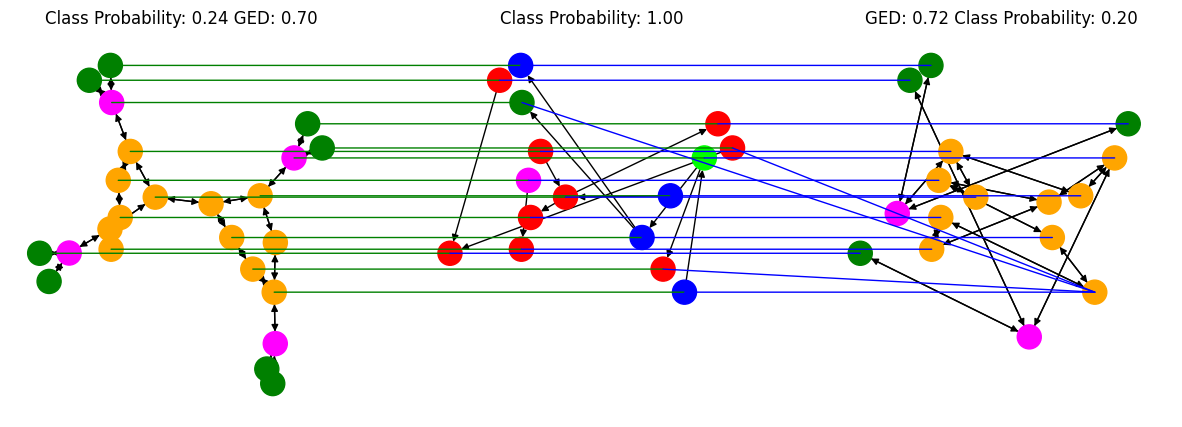

In [21]:
vis_con_graph(
    gen_gnnInt_0,
    explainee_raw, 
    dis_node_feats = 7,
    dis_edge_feats = 4, 
    obs_ex1=test_data_list_0[2].clone(), 
    obs_ex2=test_data_list_0[3].clone(), 
    target=0
)

In [22]:
gen_gnnInt_1_dropped = train_egg(
    dis_node_feats=5, 
    dis_edge_feats=3,
    explainee=explainee_dropped, 
    target=1,
    train_data_list_1=train_data_list_dropped_1 + test_data_list_dropped_1, 
    train_data_list_0=train_data_list_dropped_0 + train_data_list_dropped_0, 
    train_data_list_full=train_data_list_dropped + test_data_list_dropped, 
    pred_loss_embeds=dict(
        (k, train_avg_embedding_1_dropped[k]) 
        for k in ["conv3"] if k in train_avg_embedding_1_dropped
    ), 
    other_class_embeds=dict(
        (k, train_avg_embedding_0_dropped[k]) 
        for k in ["conv3"] if k in train_avg_embedding_0_dropped
    ), 
    loss_fn_weights = torch.tensor([1.0, 0.0, 1e-5, 0.0]), 
)

Baseline Prediction Accuracy: 
(0.0129, 0.0181)
Baseline % GED to 1
(0.0796, 0.0849)
Baseline % GED to 0
(0.0613, 0.0704)
Epoch: 0 Losses:[3.0175611105832187, -0.08780328184366226, 12797.25106534091, 2.738090141253038]
Epoch: 1 Losses:[2.9366287968375464, -0.09708813916553151, 2190.297119140625, 2.848164189945568]
Epoch: 2 Losses:[3.0713794881647285, -0.06439572403376753, 648.1367104270241, 2.9279767599972812]
Epoch: 3 Losses:[3.06955302845348, -0.06621405651623552, 236.41783974387428, 2.9920375130393286]
Epoch: 4 Losses:[3.1081970604983242, -0.05045969919724898, 97.46386441317472, 2.967225334861062]
Epoch: 5 Losses:[3.1189096840945156, -0.05014525726437569, 42.45570755004883, 2.966821486299688]
Epoch: 6 Losses:[3.1162737282839688, -0.04966821318322962, 19.530058080499824, 3.0407799807461826]
Epoch: 7 Losses:[3.099422411485152, -0.055164152925664726, 9.980148142034357, 2.912212610244751]
Epoch: 8 Losses:[3.1156585866754707, -0.051028440283103424, 5.835612687197599, 3.0280298102985728]


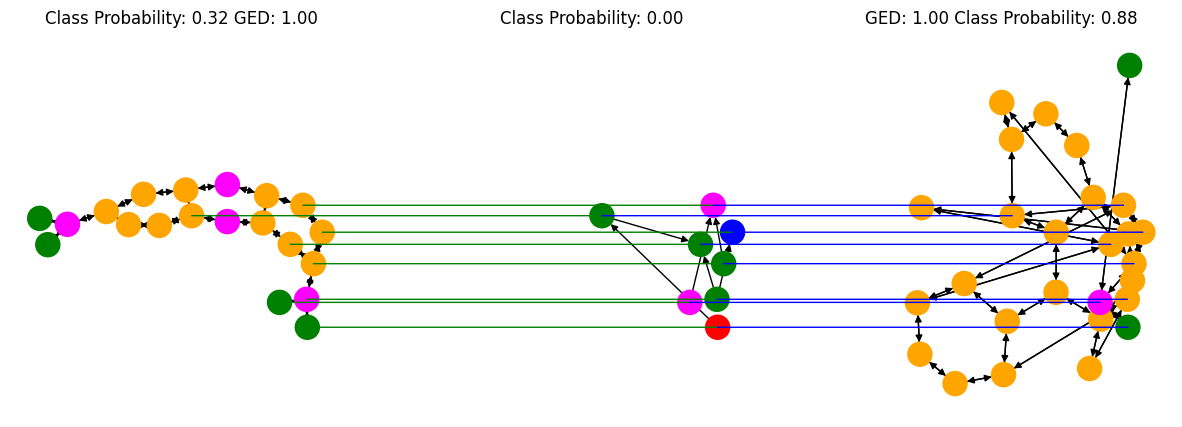

In [23]:
vis_con_graph(
    gen_gnnInt_1_dropped, 
    explainee_dropped, 
    dis_node_feats = 5,
    dis_edge_feats = 3, 
    obs_ex1=test_data_list_dropped_1[1].clone(), 
    obs_ex2=test_data_list_dropped_1[5].clone(), 
    target=1, 
    color_palette=color_palette_dropped
)

In [24]:
gen_gnnInt_0_dropped = train_egg(
    dis_node_feats=5, 
    dis_edge_feats=3,
    explainee=explainee_dropped, 
    target=0,
    train_data_list_0=train_data_list_dropped_0 + test_data_list_dropped_0, 
    train_data_list_1=train_data_list_dropped_1 + train_data_list_dropped_1, 
    train_data_list_full=train_data_list_dropped + test_data_list_dropped, 
    pred_loss_embeds=dict(
        (k, train_avg_embedding_0_dropped[k]) 
        for k in ["conv3"] if k in train_avg_embedding_0_dropped
    ), 
    other_class_embeds=dict(
        (k, train_avg_embedding_1_dropped[k]) 
        for k in ["conv3"] if k in train_avg_embedding_1_dropped
    ), 
    loss_fn_weights = torch.tensor([1.0, 0.0, 1e-5, 0.0]), 
)

Baseline Prediction Accuracy: 
(0.9934, 0.9959)
Baseline % GED to 1
(0.0759, 0.0796)
Baseline % GED to 0
(0.0646, 0.0703)
Epoch: 0 Losses:[0.38911751725456933, -1.85748751596971, 11917.831853693182, -2.444648704745553]
Epoch: 1 Losses:[0.3775087676265023, -1.8685158382762561, 2024.5123512961648, -2.6472995497963647]
Epoch: 2 Losses:[0.376339161937887, -1.8664510575207798, 654.2056857022372, -2.7057932994582434]
Epoch: 3 Losses:[0.37503001906655054, -1.8643645481629805, 251.3163396661932, -2.698033928871155]
Epoch: 4 Losses:[0.3751704692840576, -1.8643461465835571, 105.56866524436258, -2.7074240771206943]
Epoch: 5 Losses:[0.3745957775549455, -1.8620158650658347, 45.48205375671387, -2.629251144149087]
Epoch: 6 Losses:[0.3738149973479184, -1.8598857034336438, 20.465584234757856, -2.644142996181141]
Epoch: 7 Losses:[0.3733736439184709, -1.8573622920296409, 10.071417375044389, -2.570749813860113]
Epoch: 8 Losses:[0.37706378915093164, -1.8513839569958774, 5.654746922579679, -2.58972419391978

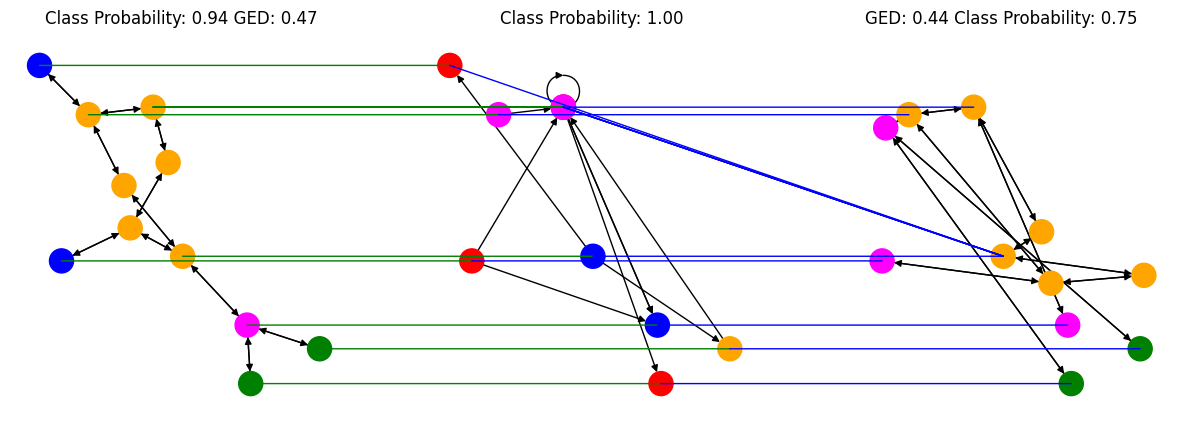

In [25]:
vis_con_graph(
    gen_gnnInt_0_dropped, 
    explainee_dropped, 
    dis_node_feats = 5,
    dis_edge_feats = 3, 
    obs_ex1=test_data_list_dropped_0[4].clone(), 
    obs_ex2=test_data_list_dropped_0[3].clone(), 
    target=0, 
    color_palette=color_palette_dropped
)

## Multi-Layer Embedding Similarity

In [26]:
gen_gnnInt_1_ml = train_egg(
    dis_node_feats=7, 
    dis_edge_feats=4,
    explainee=explainee_raw, 
    target=1,
    train_data_list_1=train_data_list_1 + test_data_list_1, 
    train_data_list_0=train_data_list_0 + train_data_list_0, 
    train_data_list_full=train_data_list + test_data_list, 
    pred_loss_embeds=dict(
        (k, train_avg_embedding_1[k]) 
        for k in ["conv1", "conv2", "conv3"] if k in train_avg_embedding_1
    ), 
    other_class_embeds=dict(
        (k, train_avg_embedding_0[k]) 
        for k in ["conv3"] if k in train_avg_embedding_0
    ), 
    loss_fn_weights = torch.tensor([1.0, 0.0, 1e-5, 0.0]), 
)

Baseline Prediction Accuracy: 
(0.0241, 0.0338)
Baseline % GED to 1
(0.0879, 0.0904)
Baseline % GED to 0
(0.0674, 0.0789)
Epoch: 0 Losses:[2.0305545546791772, -0.35848172347653995, 11550.958806818182, 2.6354544975540857]
Epoch: 1 Losses:[1.3593757260929455, -1.0245050354437395, 2053.3836669921875, 2.7416430711746216]
Epoch: 2 Losses:[1.26217397776517, -1.1732310490174727, 686.1883378462358, 2.82785346291282]
Epoch: 3 Losses:[1.0999959924004294, -1.3484959602355957, 259.62476140802556, 2.8026286363601685]
Epoch: 4 Losses:[1.0214257890527898, -1.4688816341486843, 104.93774691495028, 2.852922407063571]
Epoch: 5 Losses:[0.9586738456379283, -1.549213019284335, 44.599185423417524, 2.8279043327678335]
Epoch: 6 Losses:[0.9053146351467479, -1.607587001540444, 19.98846400867809, 2.8462421894073486]
Epoch: 7 Losses:[0.8769942792979154, -1.6526891318234531, 9.856177936900746, 2.832192973657088]
Epoch: 8 Losses:[0.9110326875339855, -1.610540357503024, 5.536492824554443, 2.8866330060091885]
Epoch: 9

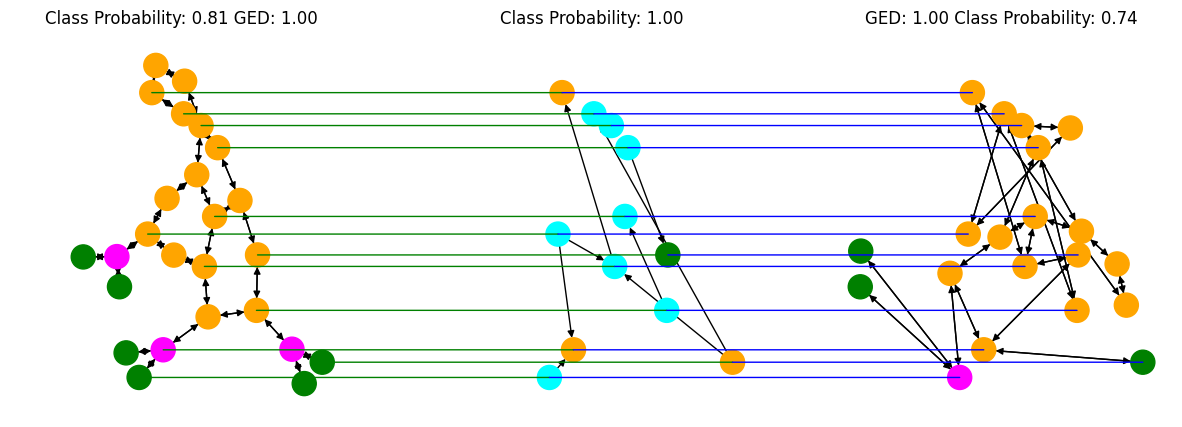

In [27]:
vis_con_graph(
    gen_gnnInt_1_ml, 
    explainee_raw, 
    dis_node_feats = 7,
    dis_edge_feats = 4, 
    obs_ex1=test_data_list_1[1].clone(), 
    obs_ex2=test_data_list_1[5].clone(), 
    target=1
)

In [28]:
gen_gnnInt_0_ml = train_egg(
    dis_node_feats=7, 
    dis_edge_feats=4,
    explainee=explainee_raw, 
    target=0,
    train_data_list_1=train_data_list_1 + test_data_list_1, 
    train_data_list_0=train_data_list_0 + train_data_list_0, 
    train_data_list_full=train_data_list + test_data_list, 
    pred_loss_embeds=dict(
        (k, train_avg_embedding_0[k]) 
        for k in ["conv1", "conv2", "conv3"] if k in train_avg_embedding_0
    ), 
    other_class_embeds=dict(
        (k, train_avg_embedding_1[k]) 
        for k in ["conv3"] if k in train_avg_embedding_1
    ), 
    loss_fn_weights = torch.tensor([1.0, 0.0, 1e-5, 0.0]), 
)

Baseline Prediction Accuracy: 
(0.8222, 0.8527)
Baseline % GED to 1
(0.0839, 0.0882)
Baseline % GED to 0
(0.0655, 0.0746)
Epoch: 0 Losses:[0.7550226558338512, -1.7970172708684748, 12304.745716441761, -2.6416731856086035]
Epoch: 1 Losses:[0.7178588292815469, -1.805950023911216, 2024.8675315163352, -2.7101107944141734]
Epoch: 2 Losses:[0.7172624089501121, -1.8289897333491931, 636.4301286177201, -2.7707917961207302]
Epoch: 3 Losses:[0.6890694824132052, -1.8302632136778398, 245.0344099564986, -2.788318460637873]
Epoch: 4 Losses:[0.7078952897678722, -1.8058485984802246, 104.92473602294922, -2.8180342479185625]
Epoch: 5 Losses:[0.6786088618365201, -1.8264108354395086, 47.40710241144354, -2.770687309178439]
Epoch: 6 Losses:[0.6775303970683705, -1.800787167115645, 22.748289108276367, -2.7091994393955576]
Epoch: 7 Losses:[0.6758585355498574, -1.8095590743151577, 11.451661543412643, -2.745826070958918]
Epoch: 8 Losses:[0.6618720184672963, -1.8302528316324407, 6.278430938720703, -2.71891392361034

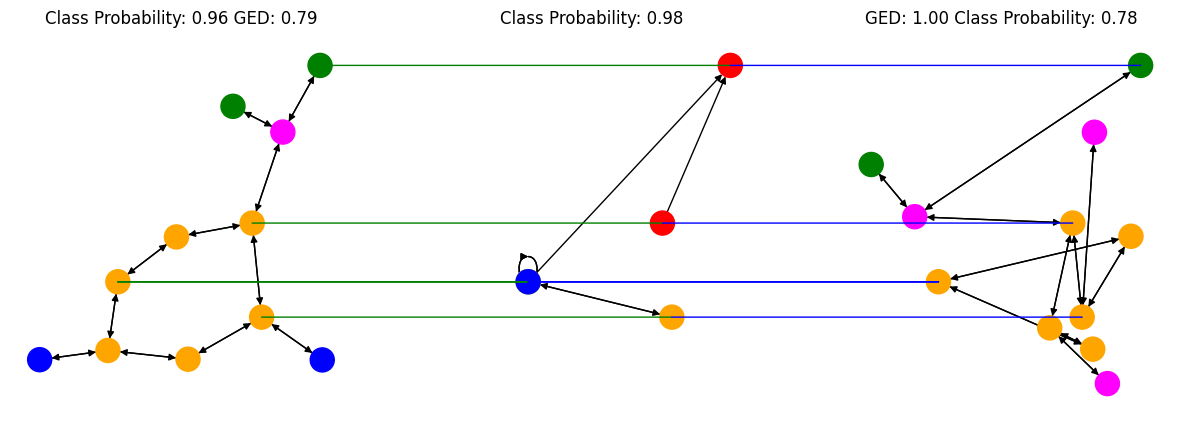

In [29]:
vis_con_graph(
    gen_gnnInt_0_ml,
    explainee_raw, 
    dis_node_feats = 7,
    dis_edge_feats = 4, 
    obs_ex1=test_data_list_0[0].clone(), 
    obs_ex2=test_data_list_0[4].clone(), 
    target=0
)

In [30]:
gen_gnnInt_1_dropped_ml = train_egg(
    dis_node_feats=5, 
    dis_edge_feats=3,
    explainee=explainee_dropped, 
    target=1,
    train_data_list_1=train_data_list_dropped_1 + test_data_list_dropped_1, 
    train_data_list_0=train_data_list_dropped_0 + train_data_list_dropped_0, 
    train_data_list_full=train_data_list_dropped + test_data_list_dropped, 
    pred_loss_embeds=dict(
        (k, train_avg_embedding_1_dropped[k]) 
        for k in ["conv1", "conv2", "conv3"] if k in train_avg_embedding_1_dropped
    ), 
    other_class_embeds=dict(
        (k, train_avg_embedding_0_dropped[k]) 
        for k in ["conv3"] if k in train_avg_embedding_0_dropped
    ), 
    loss_fn_weights = torch.tensor([1.0, 0.0, 1e-5, 0.0]), 
)

Baseline Prediction Accuracy: 
(0.0002, 0.0004)
Baseline % GED to 1
(0.0781, 0.0829)
Baseline % GED to 0
(0.0612, 0.0704)
Epoch: 0 Losses:[2.345576849850741, -0.0641037334095348, 12535.546209161932, 2.545632237737829]
Epoch: 1 Losses:[2.183889389038086, -0.05748059160330079, 2066.579012784091, 2.4129542383280667]
Epoch: 2 Losses:[1.9019184437665073, -0.13973502577705818, 643.779316295277, 2.3815866221081126]
Epoch: 3 Losses:[1.4943993850187822, -0.395767099478028, 244.07221152565697, 2.2628484097394077]
Epoch: 4 Losses:[1.0950251871889287, -0.9028023752299222, 104.91155450994319, 2.2746633887290955]
Epoch: 5 Losses:[0.9470405199310996, -1.1376324892044067, 46.0539699901234, 2.296528626572002]
Epoch: 6 Losses:[0.8994536128911105, -1.1970976753668352, 21.24411678314209, 2.2310394698923286]
Epoch: 7 Losses:[0.8787789073857394, -1.267639073458585, 10.564494089646773, 2.253612670031461]
Epoch: 8 Losses:[0.8144865198568865, -1.3437977216460488, 5.903949650851163, 2.219930123199116]
Epoch: 9 

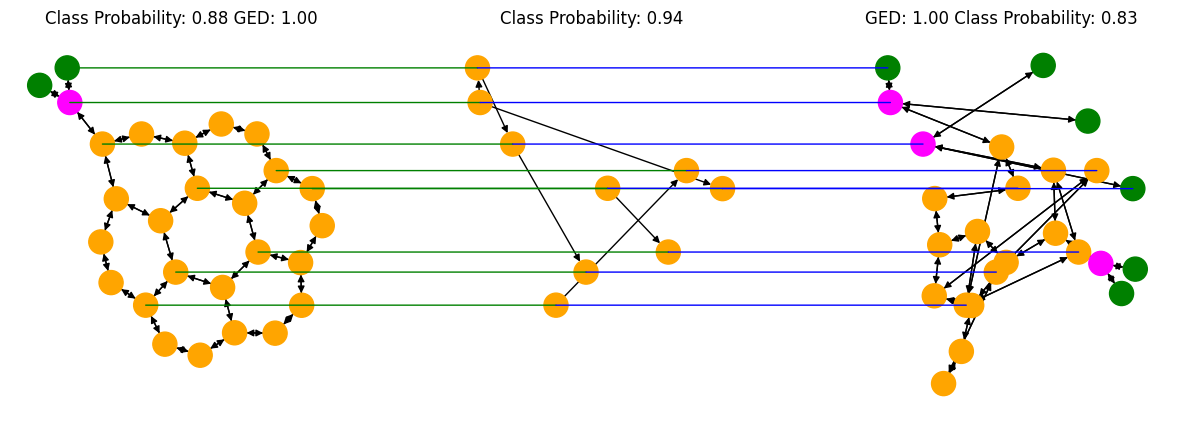

In [31]:
vis_con_graph(
    gen_gnnInt_1_dropped_ml, 
    explainee_dropped, 
    dis_node_feats = 5,
    dis_edge_feats = 3, 
    obs_ex1=test_data_list_dropped_1[5].clone(), 
    obs_ex2=test_data_list_dropped_1[4].clone(), 
    target=1, 
    color_palette=color_palette_dropped
)

In [32]:
gen_gnnInt_0_dropped_ml = train_egg(
    dis_node_feats=5, 
    dis_edge_feats=3,
    explainee=explainee_dropped, 
    target=0,
    train_data_list_0=train_data_list_dropped_0 + test_data_list_dropped_0, 
    train_data_list_1=train_data_list_dropped_1 + train_data_list_dropped_1, 
    train_data_list_full=train_data_list_dropped + test_data_list_dropped, 
    pred_loss_embeds=dict(
        (k, train_avg_embedding_0_dropped[k]) 
        for k in ["conv1", "conv2", "conv3"] if k in train_avg_embedding_0_dropped
    ), 
    other_class_embeds=dict(
        (k, train_avg_embedding_1_dropped[k]) 
        for k in ["conv3"] if k in train_avg_embedding_1_dropped
    ), 
    loss_fn_weights = torch.tensor([1.0, 0.0, 1e-5, 0.0]), 
)

Baseline Prediction Accuracy: 
(0.9563, 0.9662)
Baseline % GED to 1
(0.0741, 0.077)
Baseline % GED to 0
(0.0624, 0.0717)
Epoch: 0 Losses:[0.5712251392277804, -1.8560224338011309, 11928.357044566761, -2.3645816553722727]
Epoch: 1 Losses:[0.5078520693562247, -1.856953967701305, 1877.9445856267755, -2.3321958021684126]
Epoch: 2 Losses:[0.479258195920424, -1.8352608463980935, 582.0688726251775, -2.326271788640456]
Epoch: 3 Losses:[0.4675008410757238, -1.8280541680075906, 217.63316761363637, -2.2938239736990496]
Epoch: 4 Losses:[0.48157195340503345, -1.8019579215483232, 90.10934101451527, -2.3322859460657295]
Epoch: 5 Losses:[0.4957964393225583, -1.7630155303261497, 39.855727282437414, -2.2907910617915066]
Epoch: 6 Losses:[0.49214177240024914, -1.790150761604309, 18.39830103787509, -2.390939425338398]
Epoch: 7 Losses:[0.49217145280404523, -1.8031648830934004, 9.200466589494185, -2.4236267805099487]
Epoch: 8 Losses:[0.4961067627776753, -1.7769446698102085, 5.330169027501887, -2.3942805366082

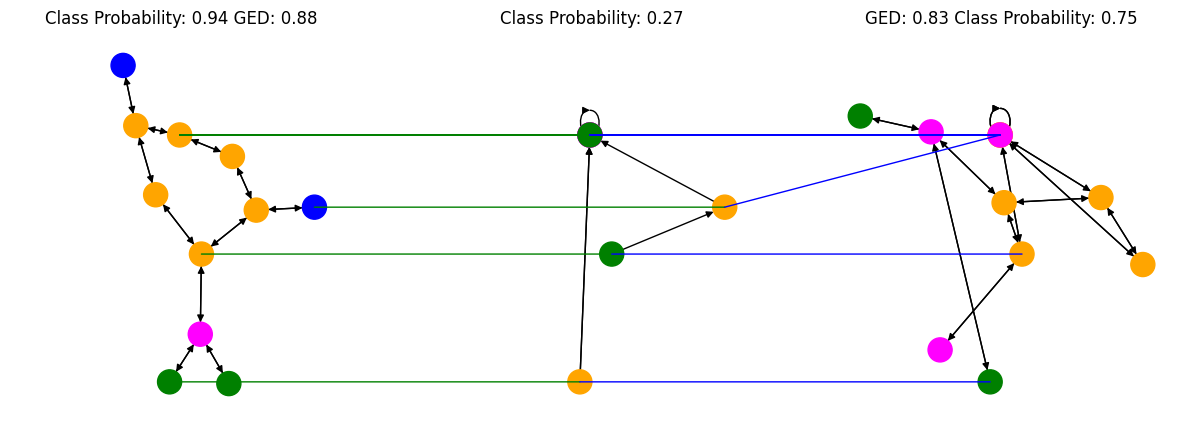

In [33]:
vis_con_graph(
    gen_gnnInt_0_dropped_ml, 
    explainee_dropped, 
    dis_node_feats = 5,
    dis_edge_feats = 3, 
    obs_ex1=test_data_list_dropped_0[4].clone(), 
    obs_ex2=test_data_list_dropped_0[3].clone(), 
    target=0, 
    color_palette=color_palette_dropped
)

## Opposing Class Embeddings

In [34]:
gen_gnnInt_1_oc = train_egg(
    dis_node_feats=7, 
    dis_edge_feats=4,
    explainee=explainee_raw, 
    target=1,
    train_data_list_1=train_data_list_1 + test_data_list_1, 
    train_data_list_0=train_data_list_0 + train_data_list_0, 
    train_data_list_full=train_data_list + test_data_list, 
    pred_loss_embeds=dict(
        (k, train_avg_embedding_1[k]) 
        for k in ["conv1", "conv2", "conv3"] if k in train_avg_embedding_1
    ), 
    other_class_embeds=dict(
        (k, train_avg_embedding_0[k]) 
        for k in ["conv1", "conv2", "conv3"] if k in train_avg_embedding_0
    ), 
    loss_fn_weights = torch.tensor([1.0, 1.0, 1e-5, 0.0]), 
)

Baseline Prediction Accuracy: 
(0.0598, 0.0759)
Baseline % GED to 1
(0.0891, 0.0938)
Baseline % GED to 0
(0.0683, 0.0817)
Epoch: 0 Losses:[1.8892300454053013, -0.5148877691138875, 11645.341796875, 2.6780267574570398]
Epoch: 1 Losses:[1.2825433666055852, -0.8057858347892761, 2543.5655406605115, 2.770584323189475]
Epoch: 2 Losses:[1.1931791413914075, -0.8692481192675504, 751.3326748934659, 2.8863374319943516]
Epoch: 3 Losses:[1.051898717880249, -0.9484715407544916, 281.3573081276634, 2.876187812198292]
Epoch: 4 Losses:[0.9517609747973356, -1.0157159566879272, 113.25433349609375, 2.985751910643144]
Epoch: 5 Losses:[0.933493131941015, -1.0447676994583823, 46.207819505171344, 3.037082856351679]
Epoch: 6 Losses:[0.8693504116751931, -1.086307937448675, 20.8931996605613, 2.929851521145214]
Epoch: 7 Losses:[0.8676297989758578, -1.0989394838159734, 9.907450979406184, 3.020049571990967]
Epoch: 8 Losses:[0.8416132385080511, -1.1121323217045178, 5.370940208435059, 3.0411407947540283]
Epoch: 9 Losse

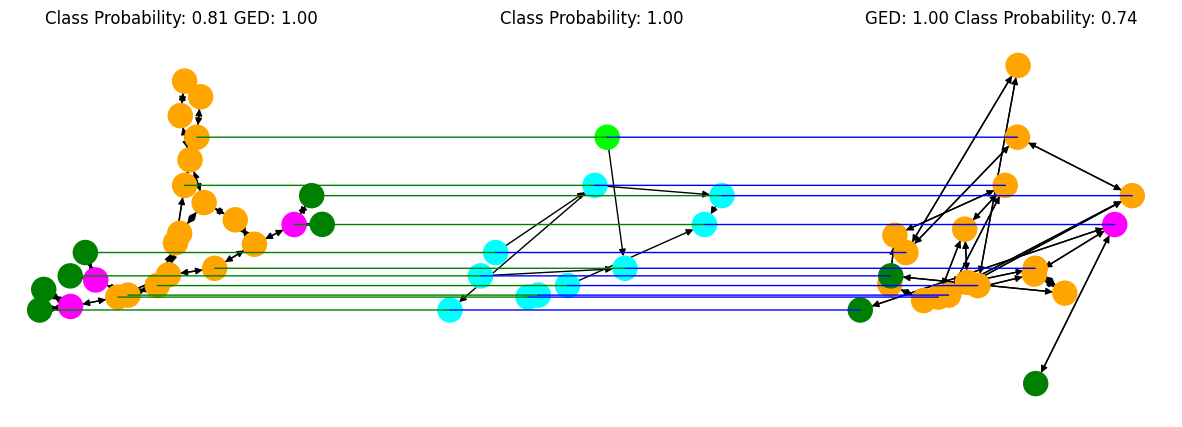

In [35]:
vis_con_graph(
    gen_gnnInt_1_oc, 
    explainee_raw, 
    dis_node_feats = 7,
    dis_edge_feats = 4, 
    obs_ex1=test_data_list_1[1].clone(), 
    obs_ex2=test_data_list_1[5].clone(), 
    target=1
)

In [36]:
gen_gnnInt_0_oc = train_egg(
    dis_node_feats=7, 
    dis_edge_feats=4,
    explainee=explainee_raw, 
    target=0,
    train_data_list_1=train_data_list_1 + test_data_list_1, 
    train_data_list_0=train_data_list_0 + train_data_list_0, 
    train_data_list_full=train_data_list + test_data_list, 
    pred_loss_embeds=dict(
        (k, train_avg_embedding_0[k]) 
        for k in ["conv1", "conv2", "conv3"] if k in train_avg_embedding_0
    ), 
    other_class_embeds=dict(
        (k, train_avg_embedding_1[k]) 
        for k in ["conv1", "conv2", "conv3"] if k in train_avg_embedding_1
    ), 
    loss_fn_weights = torch.tensor([1.0, 1.0, 1e-5, 0.0]), 
)

Baseline Prediction Accuracy: 
(0.9383, 0.9525)
Baseline % GED to 1
(0.0785, 0.0811)
Baseline % GED to 0
(0.0607, 0.07)
Epoch: 0 Losses:[0.715054067698392, -1.1215587746013294, 14497.449440696022, -2.6431119821288367]
Epoch: 1 Losses:[0.748819421638142, -1.145189491185275, 2471.4726118607955, -2.800480615008961]
Epoch: 2 Losses:[0.7399034716866233, -1.1752884171225808, 774.0691639293324, -2.8875525431199507]
Epoch: 3 Losses:[0.7315760092301802, -1.1845826777544888, 286.6827572909269, -2.9124935323541816]
Epoch: 4 Losses:[0.7447981400923296, -1.1932399489662864, 117.37164861505681, -2.912615180015564]
Epoch: 5 Losses:[0.7547398372129961, -1.1998860402540727, 51.75772614912553, -3.0727562362497505]
Epoch: 6 Losses:[0.7461523142727938, -1.2157734632492065, 24.1500977602872, -3.010695067319003]
Epoch: 7 Losses:[0.746926101771268, -1.2182825587012551, 12.042777494950728, -3.006395545872775]
Epoch: 8 Losses:[0.7540231943130493, -1.2224861925298518, 6.581281011754816, -3.0047038468447598]
Epo

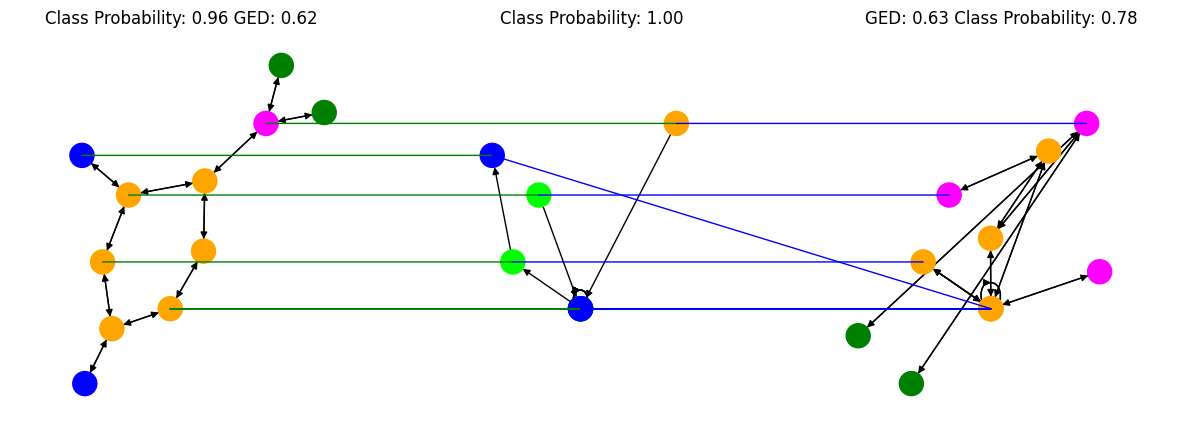

In [37]:
vis_con_graph(
    gen_gnnInt_0_oc,
    explainee_raw, 
    dis_node_feats = 7,
    dis_edge_feats = 4, 
    obs_ex1=test_data_list_0[0].clone(), 
    obs_ex2=test_data_list_0[4].clone(), 
    target=0
)

In [38]:
gen_gnnInt_1_dropped_oc = train_egg(
    dis_node_feats=5, 
    dis_edge_feats=3,
    explainee=explainee_dropped, 
    target=1,
    train_data_list_1=train_data_list_dropped_1 + test_data_list_dropped_1, 
    train_data_list_0=train_data_list_dropped_0 + train_data_list_dropped_0, 
    train_data_list_full=train_data_list_dropped + test_data_list_dropped, 
    pred_loss_embeds=dict(
        (k, train_avg_embedding_1_dropped[k]) 
        for k in ["conv1", "conv2", "conv3"] if k in train_avg_embedding_1_dropped
    ), 
    other_class_embeds=dict(
        (k, train_avg_embedding_0_dropped[k]) 
        for k in ["conv1", "conv2", "conv3"] if k in train_avg_embedding_0_dropped
    ), 
    loss_fn_weights = torch.tensor([1.0, 1.0, 1e-5, 0.0]), 
)

Baseline Prediction Accuracy: 
(0.002, 0.0038)
Baseline % GED to 1
(0.0768, 0.0826)
Baseline % GED to 0
(0.0606, 0.0684)
Epoch: 0 Losses:[2.3342250260439785, -0.22619327225468375, 11653.734752308239, 2.42933667789806]
Epoch: 1 Losses:[2.1439015106721357, -0.13877637887542899, 1865.3970281427557, 2.3538515351035376]
Epoch: 2 Losses:[1.7625465718182651, -0.19006224315274844, 584.9173639470881, 2.1803866028785706]
Epoch: 3 Losses:[1.1961216222156177, -0.42179026116024365, 253.64828768643466, 2.16498277945952]
Epoch: 4 Losses:[0.8885840611024336, -0.6243313659321178, 118.0340444391424, 2.1528247107159006]
Epoch: 5 Losses:[0.8311813311143355, -0.6954124624078925, 53.563101681795985, 2.175050134008581]
Epoch: 6 Losses:[0.7025153799490496, -0.783508376641707, 24.90867874839089, 2.1873372088779104]
Epoch: 7 Losses:[0.6514120264486833, -0.814703031019731, 12.451650619506836, 2.1911183378913184]
Epoch: 8 Losses:[0.6765391501513395, -0.81799147345803, 6.698738141493364, 2.1747409267859026]
Epoch:

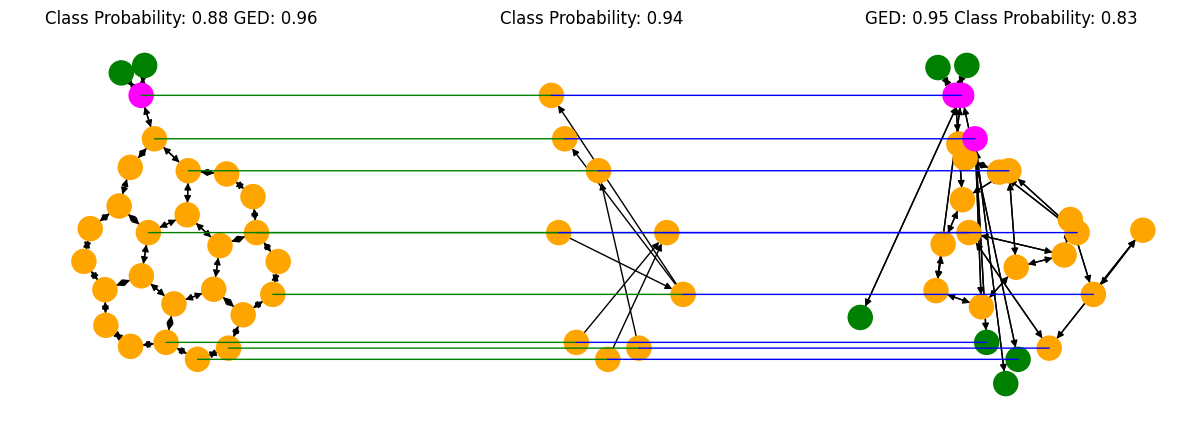

In [39]:
vis_con_graph(
    gen_gnnInt_1_dropped_oc, 
    explainee_dropped, 
    dis_node_feats = 5,
    dis_edge_feats = 3, 
    obs_ex1=test_data_list_dropped_1[5].clone(), 
    obs_ex2=test_data_list_dropped_1[4].clone(), 
    target=1, 
    color_palette=color_palette_dropped
)

In [40]:
gen_gnnInt_0_dropped_oc = train_egg(
    dis_node_feats=5, 
    dis_edge_feats=3,
    explainee=explainee_dropped, 
    target=0,
    train_data_list_0=train_data_list_dropped_0 + test_data_list_dropped_0, 
    train_data_list_1=train_data_list_dropped_1 + train_data_list_dropped_1, 
    train_data_list_full=train_data_list_dropped + test_data_list_dropped, 
    pred_loss_embeds=dict(
        (k, train_avg_embedding_0_dropped[k]) 
        for k in ["conv1", "conv2", "conv3"] if k in train_avg_embedding_0_dropped
    ), 
    other_class_embeds=dict(
        (k, train_avg_embedding_1_dropped[k]) 
        for k in ["conv1", "conv2", "conv3"] if k in train_avg_embedding_1_dropped
    ), 
    loss_fn_weights = torch.tensor([1.0, 1.0, 1e-5, 0.0]), 
)

Baseline Prediction Accuracy: 
(0.9668, 0.9749)
Baseline % GED to 1
(0.0797, 0.0825)
Baseline % GED to 0
(0.0684, 0.0711)
Epoch: 0 Losses:[0.6006321310997009, -1.0955596295270054, 11737.380260120739, -2.6113627282055942]
Epoch: 1 Losses:[0.6146283041347157, -1.1204218864440918, 1878.1350929953835, -2.860839681191878]
Epoch: 2 Losses:[0.6293442736972462, -1.140025171366605, 568.7229697487571, -2.8740473335439507]
Epoch: 3 Losses:[0.6376963095231489, -1.1486943309957331, 206.17496837269175, -2.9324778643521396]
Epoch: 4 Losses:[0.6366551084951921, -1.1483057845722546, 84.17499160766602, -2.9734267104755747]
Epoch: 5 Losses:[0.6388005126606334, -1.1509359749880703, 36.55091736533425, -3.0339291745966133]
Epoch: 6 Losses:[0.6485573866150596, -1.1620306860316882, 16.577982902526855, -3.0022108121351763]
Epoch: 7 Losses:[0.6462808793241327, -1.158523364500566, 8.324814969843084, -2.9763177850029687]
Epoch: 8 Losses:[0.646733202717521, -1.1593732075257734, 4.85808177427812, -3.028273614970120

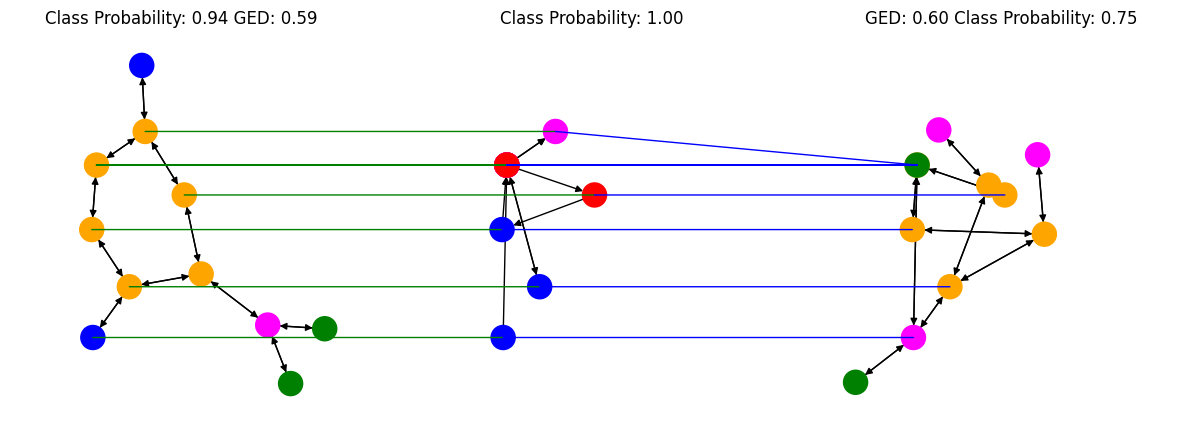

In [41]:
vis_con_graph(
    gen_gnnInt_0_dropped_oc, 
    explainee_dropped, 
    dis_node_feats = 5,
    dis_edge_feats = 3, 
    obs_ex1=test_data_list_dropped_0[4].clone(), 
    obs_ex2=test_data_list_dropped_0[3].clone(), 
    target=0, 
    color_palette=color_palette_dropped
)

## Only GED

In [42]:
gen_gnnInt_1_GED = train_egg(
    dis_node_feats=7, 
    dis_edge_feats=4,
    explainee=explainee_raw, 
    target=1,
    train_data_list_1=train_data_list_1 + test_data_list_1, 
    train_data_list_0=train_data_list_0 + train_data_list_0, 
    train_data_list_full=train_data_list + test_data_list, 
    pred_loss_embeds=dict(
        (k, train_avg_embedding_1[k]) 
        for k in ["conv1", "conv2", "conv3"] if k in train_avg_embedding_1
    ), 
    other_class_embeds=dict(
        (k, train_avg_embedding_0[k]) 
        for k in ["conv1", "conv2", "conv3"] if k in train_avg_embedding_0
    ), 
    loss_fn_weights = torch.tensor([0.0, 0.0, 1e-4, 1.0]), 
)

Baseline Prediction Accuracy: 
(0.0285, 0.0419)
Baseline % GED to 1
(0.0844, 0.088)
Baseline % GED to 0
(0.0668, 0.075)
Epoch: 0 Losses:[2.3099805441769687, -0.3577025532722473, 14110.467995383522, 2.4923436479134993]
Epoch: 1 Losses:[2.279829046942971, -0.3210375959222967, 3216.167413884943, 2.2631331248716875]
Epoch: 2 Losses:[2.0776102542877197, -0.2860583432696082, 1510.0929953835227, 2.1128579649058254]
Epoch: 3 Losses:[1.9584372693842107, -0.2506433996287259, 897.5665394176136, 1.8689338700337843]
Epoch: 4 Losses:[1.8969420194625854, -0.2260483354330063, 627.4462335759944, 1.7286656011234631]
Epoch: 5 Losses:[1.7714058702642268, -0.23937349021434784, 439.5626026500355, 1.6439739140597256]
Epoch: 6 Losses:[1.617909008806402, -0.2570586394179951, 351.2946277965199, 1.5939974188804626]
Epoch: 7 Losses:[1.5286837924610486, -0.2704895240339366, 296.66373790394175, 1.4451111880215732]
Epoch: 8 Losses:[1.45705153725364, -0.2647924761880528, 267.13451593572444, 1.3799064051021228]
Epoch:

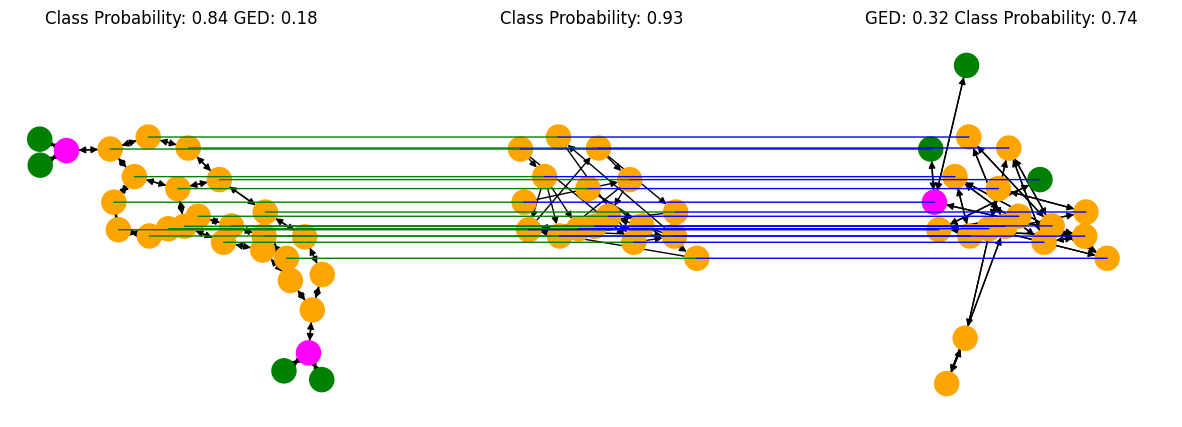

In [43]:
vis_con_graph(
    gen_gnnInt_1_GED, 
    explainee_raw, 
    dis_node_feats = 7,
    dis_edge_feats = 4, 
    obs_ex1=test_data_list_1[3].clone(), 
    obs_ex2=test_data_list_1[5].clone(), 
    target=1
)

In [44]:
gen_gnnInt_0_GED = train_egg(
    dis_node_feats=7, 
    dis_edge_feats=4,
    explainee=explainee_raw, 
    target=0,
    train_data_list_1=train_data_list_1 + test_data_list_1, 
    train_data_list_0=train_data_list_0 + train_data_list_0, 
    train_data_list_full=train_data_list + test_data_list, 
    pred_loss_embeds=dict(
        (k, train_avg_embedding_0[k]) 
        for k in ["conv1", "conv2", "conv3"] if k in train_avg_embedding_0
    ), 
    other_class_embeds=dict(
        (k, train_avg_embedding_1[k]) 
        for k in ["conv1", "conv2", "conv3"] if k in train_avg_embedding_1
    ), 
    loss_fn_weights = torch.tensor([0.0, 0.0, 1e-5, 1.0]), 
)

Baseline Prediction Accuracy: 
(0.8481, 0.8747)
Baseline % GED to 1
(0.0826, 0.0864)
Baseline % GED to 0
(0.0666, 0.0742)
Epoch: 0 Losses:[0.9055500138889659, -1.037364211949435, 15533.346546519886, -2.784236425703222]
Epoch: 1 Losses:[0.85138338804245, -1.085012132471258, 4690.356045809659, -2.874307795004411]
Epoch: 2 Losses:[0.8958946845748208, -1.0643050020391291, 2490.425692471591, -2.9293536056171763]
Epoch: 3 Losses:[0.8974123001098633, -1.0606590888716958, 1443.6906183416193, -2.9443115321072666]
Epoch: 4 Losses:[0.873634089123119, -1.064509386366064, 864.5980446555398, -2.920240348035639]
Epoch: 5 Losses:[0.8706226457249034, -1.0755475109273738, 485.26027887517756, -2.8656741597435693]
Epoch: 6 Losses:[0.8953156850554727, -1.0737683773040771, 291.10480707341975, -2.916541213339025]
Epoch: 7 Losses:[0.823659669269215, -1.0961552749980579, 177.34520235928622, -2.9359163479371504]
Epoch: 8 Losses:[0.8843189206990328, -1.077070864764127, 97.6309745094993, -2.9217549670826304]
Epoc

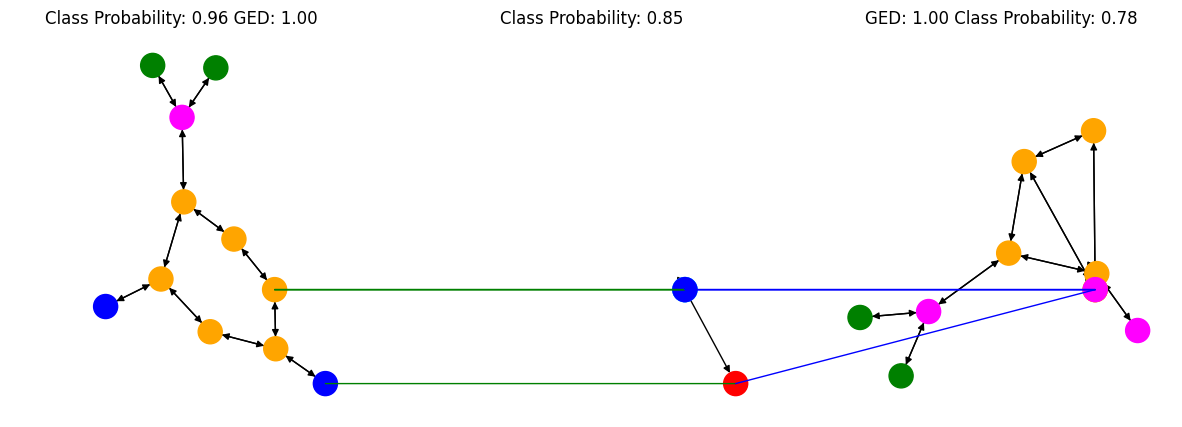

In [45]:
vis_con_graph(
    gen_gnnInt_0_GED,
    explainee_raw, 
    dis_node_feats = 7,
    dis_edge_feats = 4, 
    obs_ex1=test_data_list_0[0].clone(), 
    obs_ex2=test_data_list_0[4].clone(), 
    target=0
)

In [46]:
gen_gnnInt_1_dropped_GED = train_egg(
    dis_node_feats=5, 
    dis_edge_feats=3,
    explainee=explainee_dropped, 
    target=1,
    train_data_list_1=train_data_list_dropped_1 + test_data_list_dropped_1, 
    train_data_list_0=train_data_list_dropped_0 + train_data_list_dropped_0, 
    train_data_list_full=train_data_list_dropped + test_data_list_dropped, 
    pred_loss_embeds=dict(
        (k, train_avg_embedding_1_dropped[k]) 
        for k in ["conv1", "conv2", "conv3"] if k in train_avg_embedding_1_dropped
    ), 
    other_class_embeds=dict(
        (k, train_avg_embedding_0_dropped[k]) 
        for k in ["conv1", "conv2", "conv3"] if k in train_avg_embedding_0_dropped
    ), 
    loss_fn_weights = torch.tensor([0.0, 0.0, 1e-5, 1.0]), 
)

Baseline Prediction Accuracy: 
(0.0104, 0.0146)
Baseline % GED to 1
(0.0753, 0.0796)
Baseline % GED to 0
(0.0615, 0.0718)
Epoch: 0 Losses:[2.2943823771043257, -0.19705973023718054, 17933.66912286932, 2.0317589207129045]
Epoch: 1 Losses:[2.1752364201979204, -0.12565676461566577, 12722.424094460228, 1.6658252586017956]
Epoch: 2 Losses:[2.104967247356068, -0.10809919441288168, 11877.291725852272, 1.4542337493462996]
Epoch: 3 Losses:[2.0331841815601694, -0.1029379740357399, 11480.325461647728, 1.3843907713890076]
Epoch: 4 Losses:[1.9099155447699807, -0.12334968352859671, 11258.697265625, 1.2701634602113203]
Epoch: 5 Losses:[1.89812311259183, -0.12722598964517767, 11209.97549715909, 1.2080108333717694]
Epoch: 6 Losses:[1.7825827381827615, -0.17342096838084134, 11223.56241122159, 1.1339088678359985]
Epoch: 7 Losses:[1.6866886507381091, -0.21077555418014526, 11172.28018465909, 1.1107667359438809]
Epoch: 8 Losses:[1.5494192947040906, -0.2938426963307641, 11319.102361505682, 1.0590108064087955]

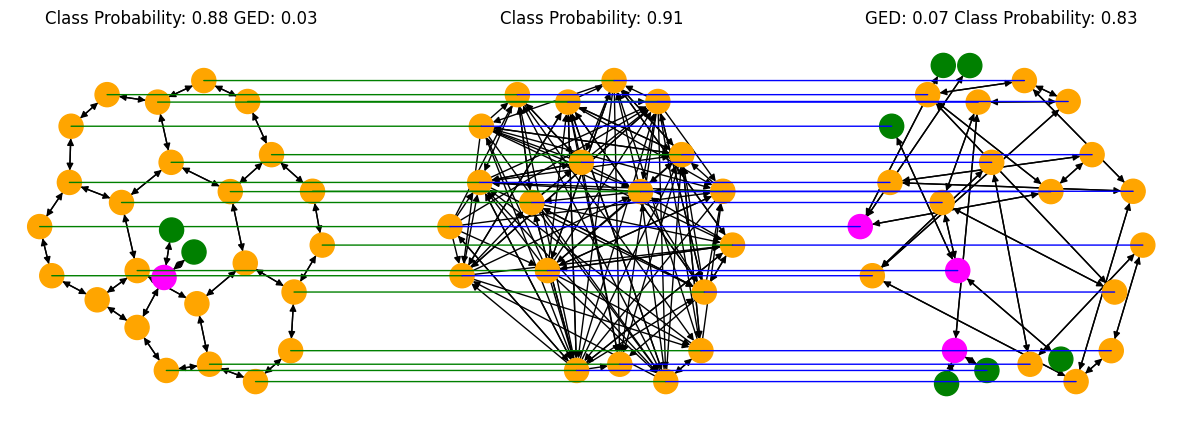

In [47]:
vis_con_graph(
    gen_gnnInt_1_dropped_GED, 
    explainee_dropped, 
    dis_node_feats = 5,
    dis_edge_feats = 3, 
    obs_ex1=test_data_list_dropped_1[5].clone(), 
    obs_ex2=test_data_list_dropped_1[4].clone(), 
    target=1, 
    color_palette=color_palette_dropped
)

In [48]:
gen_gnnInt_0_dropped_GED = train_egg(
    dis_node_feats=5, 
    dis_edge_feats=3,
    explainee=explainee_dropped, 
    target=0,
    train_data_list_0=train_data_list_dropped_0 + test_data_list_dropped_0, 
    train_data_list_1=train_data_list_dropped_1 + train_data_list_dropped_1, 
    train_data_list_full=train_data_list_dropped + test_data_list_dropped, 
    pred_loss_embeds=dict(
        (k, train_avg_embedding_0_dropped[k]) 
        for k in ["conv1", "conv2", "conv3"] if k in train_avg_embedding_0_dropped
    ), 
    other_class_embeds=dict(
        (k, train_avg_embedding_1_dropped[k]) 
        for k in ["conv1", "conv2", "conv3"] if k in train_avg_embedding_1_dropped
    ), 
    loss_fn_weights = torch.tensor([0.0, 0.0, 1e-5, 1.0]), 
)

Baseline Prediction Accuracy: 
(0.9992, 0.9996)
Baseline % GED to 1
(0.0824, 0.0843)
Baseline % GED to 0
(0.0667, 0.0766)
Epoch: 0 Losses:[0.6420294154774059, -1.1544308987530796, 13470.168812144886, -2.785851153460416]
Epoch: 1 Losses:[0.6605870669538324, -1.1734348210421475, 3734.2470481178975, -2.979782754724676]
Epoch: 2 Losses:[0.6732941811734979, -1.1844275864687832, 1803.780195756392, -3.106279503215443]
Epoch: 3 Losses:[0.680470732125369, -1.1903142712332986, 962.9516490589489, -3.1317939975044946]
Epoch: 4 Losses:[0.6865533969619058, -1.1961892409758135, 549.721210826527, -3.125262672250921]
Epoch: 5 Losses:[0.6907204660502347, -1.1990704102949663, 315.7024397416548, -3.10044049132954]
Epoch: 6 Losses:[0.6951076984405518, -1.2017718770287253, 189.72297529740766, -3.1437395377592607]
Epoch: 7 Losses:[0.7010283307595686, -1.206970756704157, 107.8255282315341, -3.209746230732311]
Epoch: 8 Losses:[0.7028851292350076, -1.2070946910164573, 54.468901200727984, -3.1097642833536323]
Ep

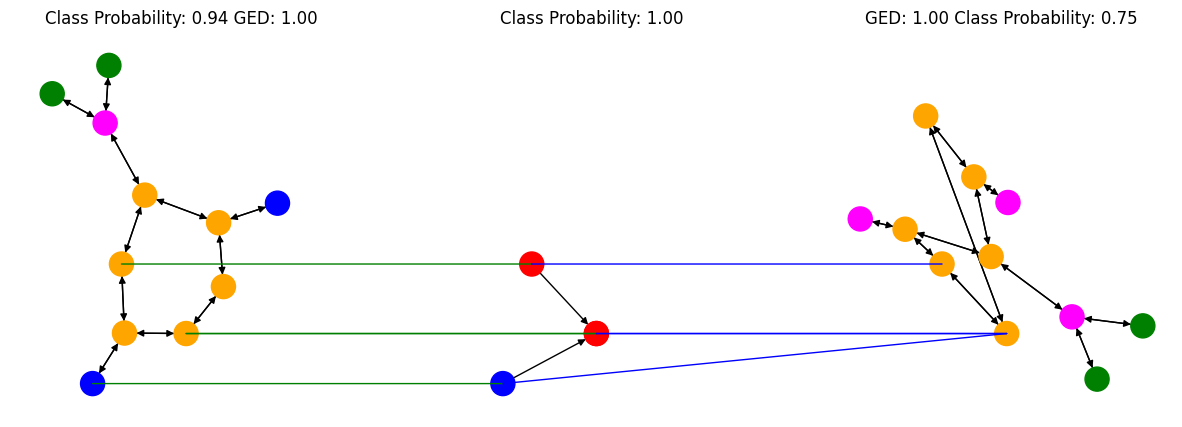

In [49]:
vis_con_graph(
    gen_gnnInt_0_dropped_GED, 
    explainee_dropped, 
    dis_node_feats = 5,
    dis_edge_feats = 3, 
    obs_ex1=test_data_list_dropped_0[4].clone(), 
    obs_ex2=test_data_list_dropped_0[3].clone(), 
    target=0, 
    color_palette=color_palette_dropped
)

## Full Loss

In [16]:
gen_gnnInt_1_full = train_egg(
    dis_node_feats=7, 
    dis_edge_feats=4,
    explainee=explainee_raw, 
    target=1,
    train_data_list_1=train_data_list_1 + test_data_list_1, 
    train_data_list_0=train_data_list_0 + train_data_list_0, 
    train_data_list_full=train_data_list + test_data_list, 
    pred_loss_embeds=dict(
        (k, train_avg_embedding_1[k]) 
        for k in ["conv1", "conv2", "conv3"] if k in train_avg_embedding_1
    ), 
    other_class_embeds=dict(
        (k, train_avg_embedding_0[k]) 
        for k in ["conv1", "conv2", "conv3"] if k in train_avg_embedding_0
    ), 
    loss_fn_weights = torch.tensor([1.0, 1.0, 1e-5, 1.0]), 
)

Baseline Prediction Accuracy: 
(0.1073, 0.1338)
Baseline % GED to 1
(0.086, 0.0899)
Baseline % GED to 0
(0.0667, 0.0778)
Epoch: 0 Losses:[1.5497633868997747, -0.6445240513844923, 21782.528586647728, 2.4092113104733555]
Epoch: 1 Losses:[0.9560478221286427, -0.9155097928914157, 15685.926047585228, 2.2534774216738613]
Epoch: 2 Losses:[0.7322235107421875, -1.0437701832164417, 14493.36709872159, 2.1132967986843805]
Epoch: 3 Losses:[0.7233857349915938, -1.0447092706506902, 14151.64737215909, 1.8822021972049365]
Epoch: 4 Losses:[0.7003464644605463, -1.0250663757324219, 13834.10848721591, 1.839245855808258]
Epoch: 5 Losses:[0.6620623523538763, -1.0365520824085583, 13829.282492897728, 1.7372593039816075]
Epoch: 6 Losses:[0.6618641073053534, -1.0100522149692883, 13798.218927556818, 1.6553832482207904]
Epoch: 7 Losses:[0.6320123509927229, -0.9955574599179354, 13709.592507102272, 1.5754286430098794]
Epoch: 8 Losses:[0.6062788800759749, -0.9863218448378823, 13463.8017578125, 1.4694582630287518]
Epo

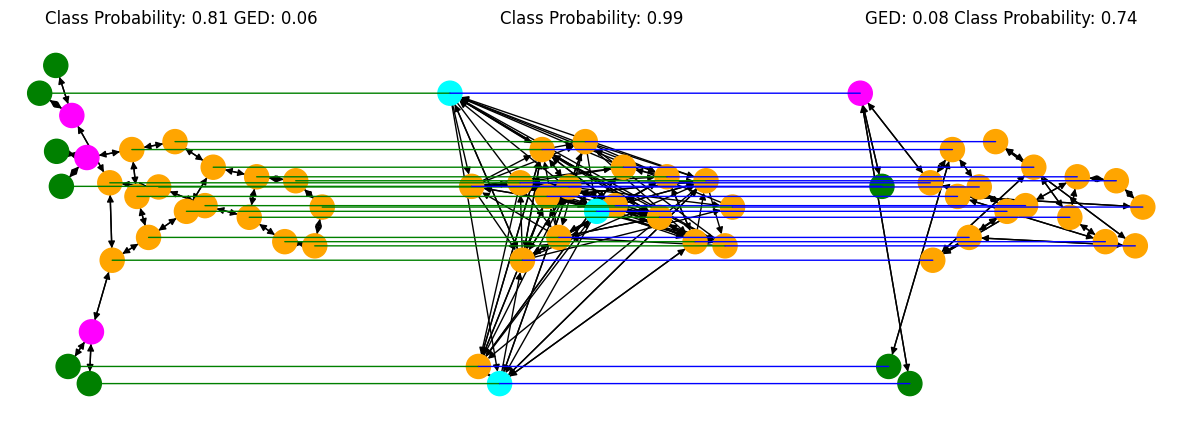

In [20]:
vis_con_graph(
    gen_gnnInt_1_full, 
    explainee_raw, 
    dis_node_feats = 7,
    dis_edge_feats = 4, 
    obs_ex1=test_data_list_1[1].clone(), 
    obs_ex2=test_data_list_1[5].clone(), 
    target=1
)

In [21]:
gen_gnnInt_0_full = train_egg(
    dis_node_feats=7, 
    dis_edge_feats=4,
    explainee=explainee_raw, 
    target=0,
    train_data_list_1=train_data_list_1 + test_data_list_1, 
    train_data_list_0=train_data_list_0 + train_data_list_0, 
    train_data_list_full=train_data_list + test_data_list, 
    pred_loss_embeds=dict(
        (k, train_avg_embedding_0[k]) 
        for k in ["conv1", "conv2", "conv3"] if k in train_avg_embedding_0
    ), 
    other_class_embeds=dict(
        (k, train_avg_embedding_1[k]) 
        for k in ["conv1", "conv2", "conv3"] if k in train_avg_embedding_1
    ), 
    loss_fn_weights = torch.tensor([1.0, 1.0, 1e-5, 1.0]), 
)

Baseline Prediction Accuracy: 
(0.8952, 0.9153)
Baseline % GED to 1
(0.0824, 0.0855)
Baseline % GED to 0
(0.0669, 0.0734)
Epoch: 0 Losses:[0.7632681402293119, -1.139358726414767, 15205.279163707386, -2.7689707279205322]
Epoch: 1 Losses:[0.7563445784828879, -1.186336961659518, 3925.6213156960225, -2.8738469535654243]
Epoch: 2 Losses:[0.778686442158439, -1.1975432309237393, 1916.2563698508523, -2.9922671534798364]
Epoch: 3 Losses:[0.7953055988658558, -1.210767074064775, 1123.2404840642755, -2.987576723098755]
Epoch: 4 Losses:[0.7872639406811107, -1.2247351949865168, 670.4342762340199, -2.9669886393980547]
Epoch: 5 Losses:[0.7776799201965332, -1.23744168064811, 404.75028852982956, -2.952068101276051]
Epoch: 6 Losses:[0.7954393137585033, -1.2284987406297163, 267.5982402454723, -2.899359096180309]
Epoch: 7 Losses:[0.7940135381438516, -1.2422850240360608, 167.16571738503197, -2.9654491164467554]
Epoch: 8 Losses:[0.7903458746996793, -1.2416206815026023, 107.70147774436258, -2.9277173930948432

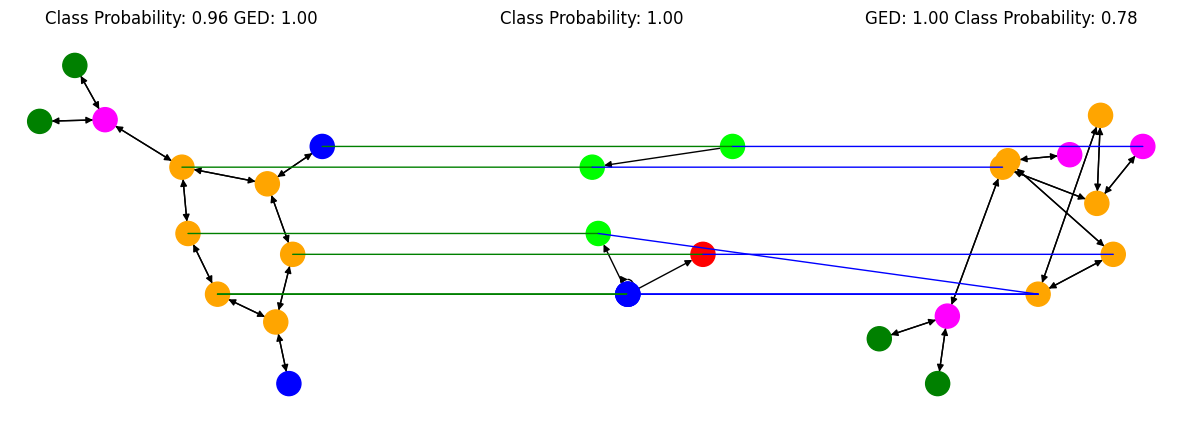

In [25]:
vis_con_graph(
    gen_gnnInt_0_full,
    explainee_raw, 
    dis_node_feats = 7,
    dis_edge_feats = 4, 
    obs_ex1=test_data_list_0[0].clone(), 
    obs_ex2=test_data_list_0[4].clone(), 
    target=0
)

In [ ]:
gen_gnnInt_1_dropped_full = train_egg(
    dis_node_feats=5, 
    dis_edge_feats=3,
    explainee=explainee_dropped, 
    target=1,
    train_data_list_1=train_data_list_dropped_1 + test_data_list_dropped_1, 
    train_data_list_0=train_data_list_dropped_0 + train_data_list_dropped_0, 
    train_data_list_full=train_data_list_dropped + test_data_list_dropped, 
    pred_loss_embeds=dict(
        (k, train_avg_embedding_1_dropped[k]) 
        for k in ["conv1", "conv2", "conv3"] if k in train_avg_embedding_1_dropped
    ), 
    other_class_embeds=dict(
        (k, train_avg_embedding_0_dropped[k]) 
        for k in ["conv1", "conv2", "conv3"] if k in train_avg_embedding_0_dropped
    ), 
    loss_fn_weights = torch.tensor([1.0, 1.0, 1e-5, 1.0]), 
    epochs=25
)

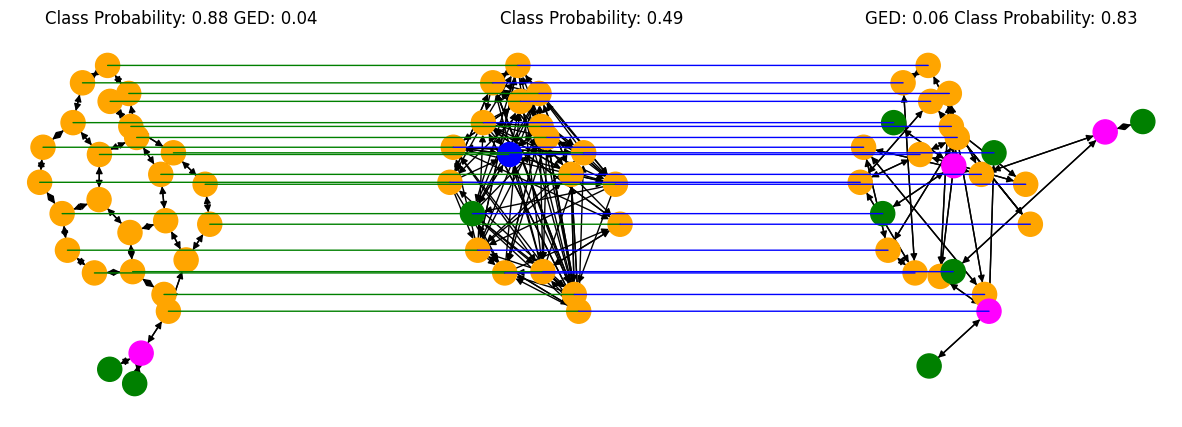

In [55]:
vis_con_graph(
    gen_gnnInt_1_dropped_full, 
    explainee_dropped, 
    dis_node_feats = 5,
    dis_edge_feats = 3, 
    obs_ex1=test_data_list_dropped_1[5].clone(), 
    obs_ex2=test_data_list_dropped_1[4].clone(), 
    target=1, 
    color_palette=color_palette_dropped
)

In [56]:
gen_gnnInt_0_dropped_full = train_egg(
    dis_node_feats=5, 
    dis_edge_feats=3,
    explainee=explainee_dropped, 
    target=0,
    train_data_list_0=train_data_list_dropped_0 + test_data_list_dropped_0, 
    train_data_list_1=train_data_list_dropped_1 + train_data_list_dropped_1, 
    train_data_list_full=train_data_list_dropped + test_data_list_dropped, 
    pred_loss_embeds=dict(
        (k, train_avg_embedding_0_dropped[k]) 
        for k in ["conv1", "conv2", "conv3"] if k in train_avg_embedding_0_dropped
    ), 
    other_class_embeds=dict(
        (k, train_avg_embedding_1_dropped[k]) 
        for k in ["conv1", "conv2", "conv3"] if k in train_avg_embedding_1_dropped
    ), 
    loss_fn_weights = torch.tensor([1.0, 1.0, 1e-5, 1.0]), 
)

Baseline Prediction Accuracy: 
(0.9884, 0.9921)
Baseline % GED to 1
(0.0794, 0.0822)
Baseline % GED to 0
(0.0664, 0.0698)
Epoch: 0 Losses:[0.6217087398875843, -1.1357576196843928, 14620.8193359375, -2.7144043012098833]
Epoch: 1 Losses:[0.6401756460016425, -1.1570202654058284, 4294.768710049716, -3.0191417173905806]
Epoch: 2 Losses:[0.6467390927401456, -1.163257122039795, 2075.2388916015625, -3.0656265670602973]
Epoch: 3 Losses:[0.6549692479046908, -1.170789046721025, 1058.4116932262075, -3.0874790386720137]
Epoch: 4 Losses:[0.6572569229386069, -1.1720525459809736, 577.7509155273438, -3.1257104223424736]
Epoch: 5 Losses:[0.6602923544970426, -1.1745886477557095, 324.1438806707209, -3.1169128201224585]
Epoch: 6 Losses:[0.6674334406852722, -1.1803346330469304, 202.11054715243253, -3.141566124829379]
Epoch: 7 Losses:[0.6658508398316123, -1.1794909672303633, 119.54460213401101, -3.1274212165312334]
Epoch: 8 Losses:[0.6716013550758362, -1.1843985427509656, 64.62689590454102, -3.08929173512892

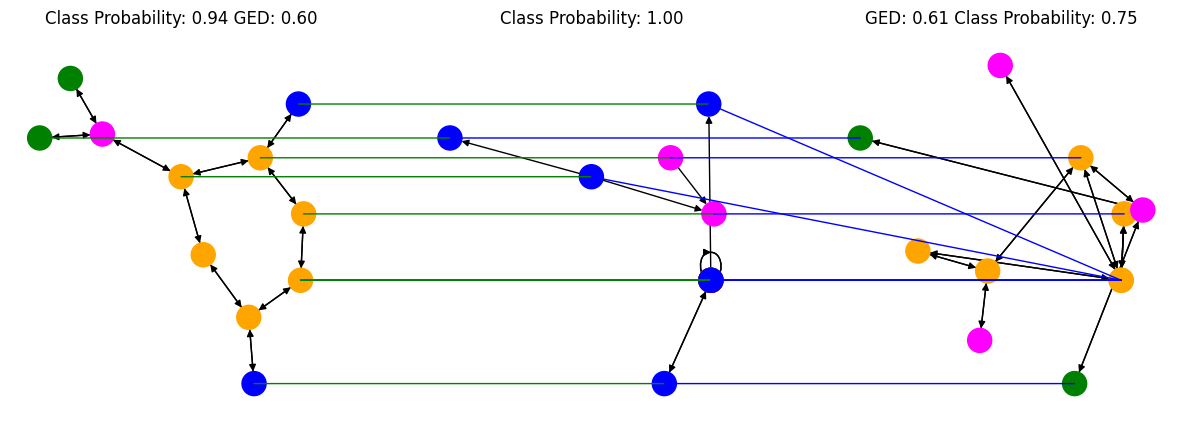

In [57]:
vis_con_graph(
    gen_gnnInt_0_dropped_oc, 
    explainee_dropped, 
    dis_node_feats = 5,
    dis_edge_feats = 3, 
    obs_ex1=test_data_list_dropped_0[4].clone(), 
    obs_ex2=test_data_list_dropped_0[3].clone(), 
    target=0, 
    color_palette=color_palette_dropped
)

## Parameter Distribution

In [27]:
data_0 = train_data_list_0 + test_data_list_0
data_1 = train_data_list_1 + test_data_list_1

batch_0 = pyg.data.Batch.from_data_list(data_0)
batch_1 = pyg.data.Batch.from_data_list(data_1)

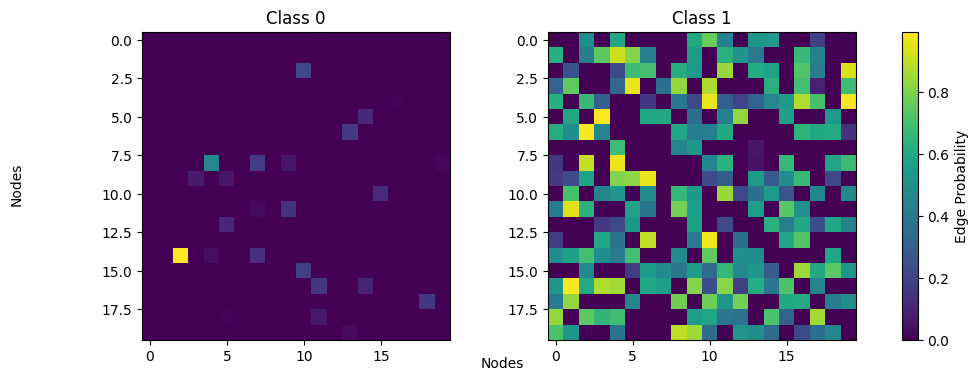

In [29]:
edge_probs_0 = gen_gnnInt_0_full.AdjacencyMatrix.probs
edge_probs_0 = edge_probs_0.detach().cpu().numpy()

edge_probs_1 = gen_gnnInt_1_full.AdjacencyMatrix.probs
edge_probs_1 = edge_probs_1.detach().cpu().numpy()

# edge_probs_untrained = generator_untrained.AdjacencyMatrix.probs
# edge_probs_untrained = edge_probs_untrained.detach().cpu().numpy()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

im0 = axes[0].imshow(edge_probs_0, cmap='viridis', interpolation='nearest')
im1 = axes[1].imshow(edge_probs_1, cmap='viridis', interpolation='nearest')
#im2 = axes[2].imshow(edge_probs_untrained, cmap='viridis', interpolation='nearest')

# Add a common color bar
cbar = fig.colorbar(im1, ax=axes.ravel().tolist())
cbar.set_label('Edge Probability')

# Set titles
axes[0].set_title('Class 0')
axes[1].set_title('Class 1')
# axes[2].set_title('Untrained')

# Set common x and y labels
fig.text(0.45, 0.04, 'Nodes', ha='center')
fig.text(0.04, 0.5, 'Nodes', va='center', rotation='vertical')

plt.show()

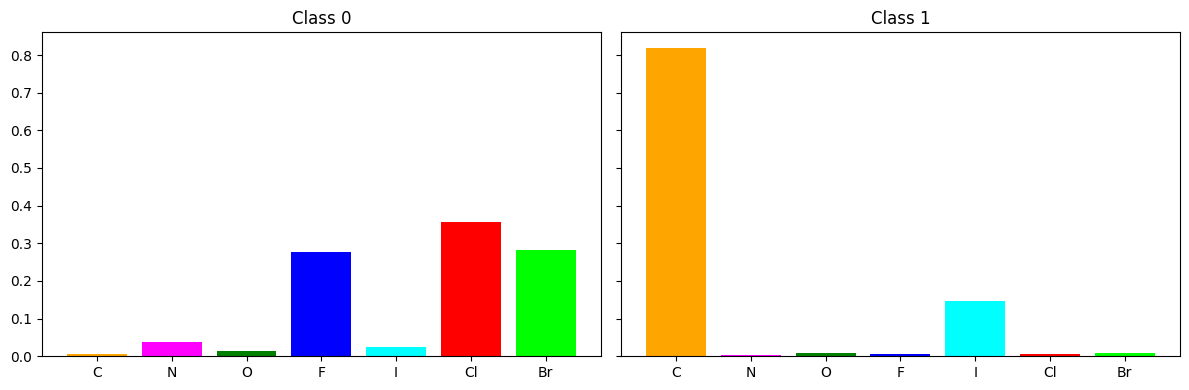

In [30]:
cell_type_probs_0 = torch.softmax(gen_gnnInt_0_full.DisNodeFeats[0].probs, dim=0)
cell_type_probs_0 = cell_type_probs_0.detach().cpu().numpy()

cell_type_probs_1 = torch.softmax(gen_gnnInt_1_full.DisNodeFeats[0].probs, dim=0)
cell_type_probs_1 = cell_type_probs_1.detach().cpu().numpy()

# cell_type_probs_untrained = torch.softmax(
#     generator_untrained.DisNodeFeats[0].probs, dim=0)
# cell_type_probs_untrained = cell_type_probs_untrained.detach().cpu().numpy()

plot_indices = ['C', 'N', 'O', 'F', "I", "Cl", 'Br']
edge_types = ['aromatic', 'single', 'double', 'triple']

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)

axes[0].bar(plot_indices, cell_type_probs_0, color=color_palette)
axes[1].bar(plot_indices, cell_type_probs_1, color=color_palette)
#axes[2].bar(plot_indices, cell_type_probs_untrained, color=color_palette)

axes[0].set_title('Class 0')
axes[1].set_title('Class 1')
#axes[2].set_title('Untrained')

plt.tight_layout()
plt.show()

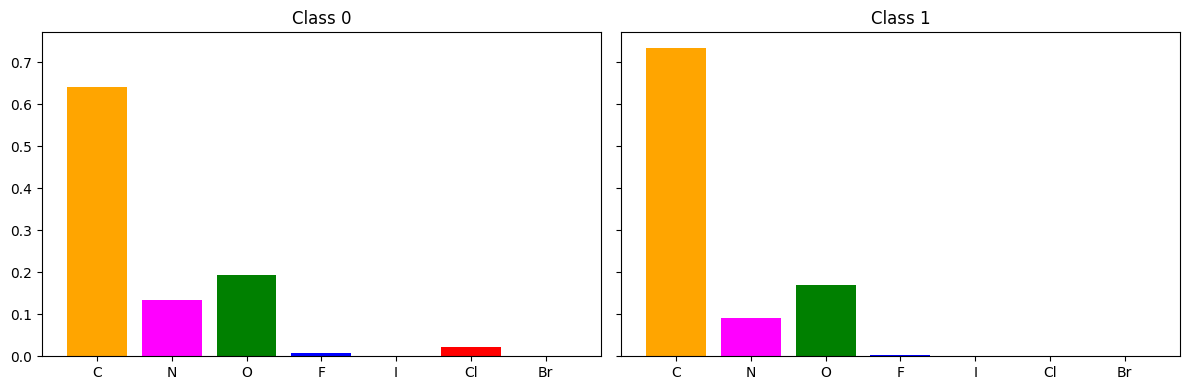

In [31]:
emp_dist_node_0 = batch_0.x.argmax(dim=-1).numpy()
emp_dist_node_1 = batch_1.x.argmax(dim=-1).numpy()

# Empirical node type probabilities
unique_classes_0, counts_0 = np.unique(emp_dist_node_0, return_counts=True)
percentages_0 = (counts_0 / len(emp_dist_node_0))
percentages_0 = np.insert(percentages_0, 4, 0.0) # missing I

unique_classes_1, counts_1 = np.unique(emp_dist_node_1, return_counts=True)
percentages_1 = (counts_1 / len(emp_dist_node_1))

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)

plot_indices = ['C', 'N', 'O', 'F', "I", "Cl", 'Br']

axes[0].bar(plot_indices, percentages_0, color=color_palette)
axes[1].bar(plot_indices, percentages_1, color=color_palette)

axes[0].set_title('Class 0')
axes[1].set_title('Class 1')

plt.tight_layout()
plt.show()

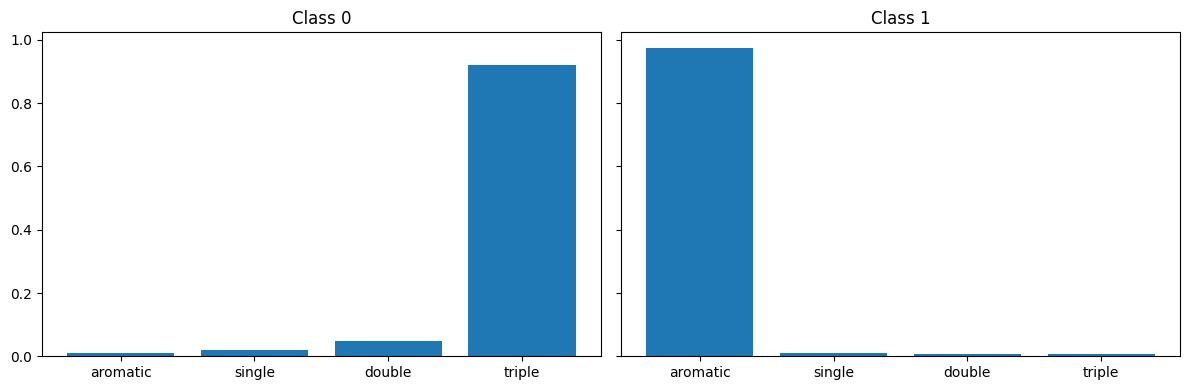

In [32]:
edge_type_probs_0 = torch.softmax(gen_gnnInt_0_full.DisEdgeFeats[0].probs, dim=0)
edge_type_probs_0 = edge_type_probs_0.detach().cpu().numpy()

edge_type_probs_1 = torch.softmax(gen_gnnInt_1_full.DisEdgeFeats[0].probs, dim=0)
edge_type_probs_1 = edge_type_probs_1.detach().cpu().numpy()

# edge_type_probs_untrained = torch.softmax(
#     generator_untrained.DisEdgeFeats[0].probs, dim=0)
# edge_type_probs_untrained = edge_type_probs_untrained.detach().cpu().numpy()

plot_indices = ['aromatic', 'single', 'double', 'triple']

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)

axes[0].bar(plot_indices, edge_type_probs_0)
axes[1].bar(plot_indices, edge_type_probs_1)
#axes[2].bar(plot_indices, edge_type_probs_untrained)

axes[0].set_title('Class 0')
axes[1].set_title('Class 1')
#axes[2].set_title('Untrained')

plt.tight_layout()
plt.show()

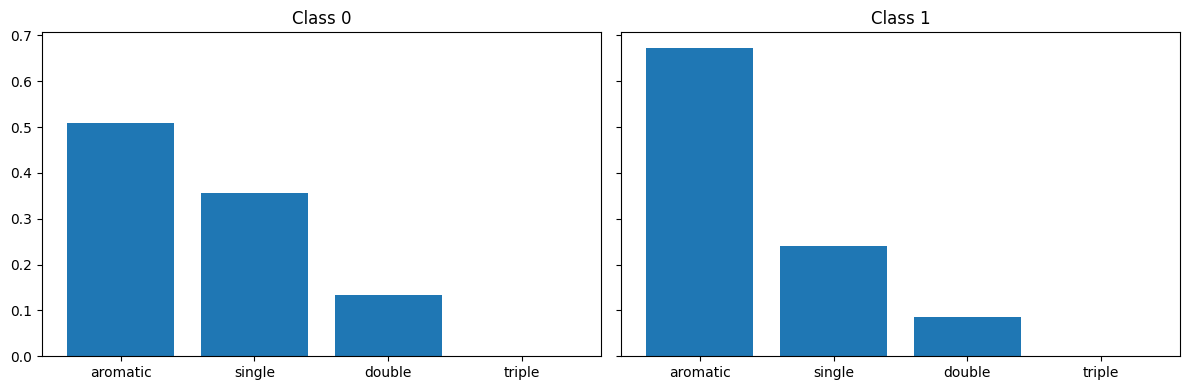

In [33]:
# Empirical edge type probabilities
emp_dist_edge_0 = batch_0.edge_attr.argmax(dim=-1).numpy()
emp_dist_edge_1 = batch_1.edge_attr.argmax(dim=-1).numpy()

unique_classes_0, counts_0 = np.unique(emp_dist_edge_0, return_counts=True)
percentages_0 = (counts_0 / len(emp_dist_edge_0))
percentages_0 = np.insert(percentages_0, 3, 0.0) # no triples. 

unique_classes_1, counts_1 = np.unique(emp_dist_edge_1, return_counts=True)
percentages_1 = (counts_1 / len(emp_dist_edge_1))

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)

axes[0].bar(edge_types, percentages_0)
axes[1].bar(edge_types, percentages_1)

axes[0].set_title('Class 0')
axes[1].set_title('Class 1')

plt.tight_layout()
plt.show()

### Clean-UP

In [34]:
import gc

# Get all objects in the current context
for obj in gc.get_objects():
    if torch.is_tensor(obj) and obj.is_cuda:
        del obj

# Clear the cache
torch.cuda.empty_cache()

# Optionally synchronize (wait for GPU computations to finish)
torch.cuda.synchronize()

/work/DPDS/s224833/Dissertation/gnn-egg/env/egg-env-38/lib/python3.8/site-packages/torch/distributed/distributed_c10d.py:293: UserWarning: torch.distributed.reduce_op is deprecated, please use torch.distributed.ReduceOp instead
  warnings.warn(
